# DATATHON 2026 - Phân tích khám phá dữ liệu cho tăng trưởng lợi nhuận

In [283]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

DATA_DIR_CANDIDATES = [
    Path(r"D:\thao\d\datathon-2026-F.E.N.S\datathon-2026-round-1"),
    Path("/kaggle/input/datathon-2026-round-1"),

]

for candidate in DATA_DIR_CANDIDATES:
    if candidate.exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Khong tim thay thu muc dataset. Hay cap nhat DATA_DIR_CANDIDATES cho dung may cua ban."
    )

print(f"Using dataset from: {DATA_DIR}")


Using dataset from: D:\thao\d\datathon-2026-F.E.N.S\datathon-2026-round-1


In [284]:
TABLE_FILES = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "sample_submission": "sample_submission.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}

DATE_COLUMNS = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}


def load_tables(data_dir, table_files, date_columns):
    tables = {}
    for table_name, file_name in table_files.items():
        tables[table_name] = pd.read_csv(
            data_dir / file_name,
            parse_dates=date_columns.get(table_name),
        )
    return tables


tables = load_tables(DATA_DIR, TABLE_FILES, DATE_COLUMNS)

products = tables["products"]
customers = tables["customers"]
promotions = tables["promotions"]
geography = tables["geography"]
orders = tables["orders"]
order_items = tables["order_items"]
payments = tables["payments"]
shipments = tables["shipments"]
returns = tables["returns"]
reviews = tables["reviews"]
sales = tables["sales"]
sample_sub = tables["sample_submission"]
inventory = tables["inventory"]
web_traffic = tables["web_traffic"]

print("=== DATASET OVERVIEW ===")
for table_name, table_df in tables.items():
    print(f"{table_name:20s} shape = {table_df.shape}")


C:\Users\Admin\AppData\Local\Temp\ipykernel_18044\2041488861.py:34: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  tables[table_name] = pd.read_csv(


=== DATASET OVERVIEW ===
products             shape = (2412, 8)
customers            shape = (121930, 7)
promotions           shape = (50, 10)
geography            shape = (39948, 4)
orders               shape = (646945, 8)
order_items          shape = (714669, 7)
payments             shape = (646945, 4)
shipments            shape = (566067, 4)
returns              shape = (39939, 7)
reviews              shape = (113551, 7)
sales                shape = (3833, 3)
sample_submission    shape = (548, 3)
inventory            shape = (60247, 17)
web_traffic          shape = (3652, 7)


## Hàm hỗ trợ và giao diện hiển thị

- Mục tiêu: chuẩn hóa theme Datathon, helper formatting và style biểu đồ để toàn bộ notebook nhìn thống nhất từ trên xuống dưới.

In [285]:
PALETTE = {
    "black": "#171717",
    "dark_gray": "#2B2B2B",
    "green": "#8CFF5A",
    "lime_green": "#A3FF6A",
    "white": "#FFFFFF",
    "light_gray": "#F2F4F3",
    "mid_gray": "#B8B8B8",
    "risk_red": "#FF5A5F",
    "warning": "#FFB020",
    "info_blue": "#4DA3FF",
    "base_bar": "#5A6472",
}

plt.rcParams.update(
    {
        "figure.facecolor": PALETTE["white"],
        "axes.facecolor": PALETTE["light_gray"],
        "axes.edgecolor": PALETTE["dark_gray"],
        "axes.labelcolor": PALETTE["black"],
        "axes.grid": True,
        "grid.color": PALETTE["mid_gray"],
        "grid.alpha": 0.4,
        "grid.linestyle": "--",
        "text.color": PALETTE["black"],
        "xtick.color": PALETTE["dark_gray"],
        "ytick.color": PALETTE["dark_gray"],
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "legend.fontsize": 11,
    }
)
sns.set_theme(style="whitegrid")


def clean_axis(ax, xlabel: str = "", ylabel: str = "", title: str = "") -> None:
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", color=PALETTE["black"], pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, color=PALETTE["dark_gray"])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, color=PALETTE["dark_gray"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_bar_labels(ax, fmt="{:.1f}", unit: str = "", pct: bool = False, y_padding: float | None = None):
    heights = [patch.get_height() for patch in ax.patches if not np.isnan(patch.get_height())]
    if not heights:
        return
    offset = y_padding if y_padding is not None else max(heights) * 0.015
    for patch in ax.patches:
        value = patch.get_height()
        if np.isnan(value):
            continue
        label = f"{value:.1f}%" if pct else fmt.format(value)
        label += unit
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + offset,
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=PALETTE["dark_gray"],
        )


def add_hbar_labels(ax, fmt="{:.1f}", pct: bool = False):
    for patch in ax.patches:
        value = patch.get_width()
        if np.isnan(value):
            continue
        label = f"{value:.1f}%" if pct else fmt.format(value)
        ax.annotate(
            label,
            xy=(value, patch.get_y() + patch.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=PALETTE["dark_gray"],
        )


def count_frame(series: pd.Series, label: str) -> pd.DataFrame:
    counts = series.fillna("Không xác định").astype(str).value_counts()
    return counts.rename_axis(label).reset_index(name="count")


def format_currency(value):
    return "N/A" if pd.isna(value) else f"{value:,.0f}"


def format_number(value):
    return "N/A" if pd.isna(value) else f"{value:,.0f}"


def format_pct(value):
    return "N/A" if pd.isna(value) else f"{value:.2%}"


def format_period(value):
    return "N/A" if pd.isna(value) else pd.to_datetime(value).strftime("%Y-%m")


def format_hundred_millions(value):
    return "N/A" if pd.isna(value) else f"{value / 1e8:,.1f}"


def axis_tram_trieu(x, pos):
    return f"{x / 1e8:,.0f}"


def axis_phan_tram(x, pos):
    return f"{x:.0f}%"

## Tổng quan hướng phân tích

### Vì sao chọn góc nhìn khách hàng?

Bộ dữ liệu có quy mô đủ lớn để phân tích sâu theo khách hàng — hơn **120,000 khách hàng**, hơn **600,000 đơn hàng**, trải dài gần **11 năm** giao dịch.

Thay vì chỉ dừng ở câu hỏi "tháng nào doanh thu cao" hay "sản phẩm nào bán chạy", hướng tiếp cận **Customer-centric** giúp trả lời những câu hỏi có giá trị kinh doanh thực sự hơn:

- Ai là nhóm khách hàng tạo ra phần lớn doanh thu và lợi nhuận?
- Nhóm nào đang có nguy cơ rời bỏ?
- Khách hàng có phụ thuộc vào khuyến mãi để mua hàng không?
- Có thể tăng doanh thu bằng cross-sell, up-sell hoặc cá nhân hoá marketing không?

Từ đó, bài EDA không chỉ dừng ở mô tả dữ liệu mà hướng đến **đề xuất hành động cụ thể** cho doanh nghiệp.

---

### Framework phân tích
Customer Insight  →  Marketing Strategy  →  Business Impact

- **Customer Insight:** Hiểu rõ hành vi, giá trị và rủi ro của từng nhóm khách hàng (RFM, cohort, profitability, discount dependency).
- **Marketing Strategy:** Chuyển insight thành chiến lược cụ thể — loyalty program, win-back campaign, cross-sell, tối ưu kênh acquisition.
- **Business Impact:** Đo tác động bằng gross profit, retention rate, AOV, CLV proxy, return rate — không chỉ dừng ở doanh thu.

## Tổng quan nhanh về dữ liệu


#### Danh mục sản phẩm phân bố như thế nào?



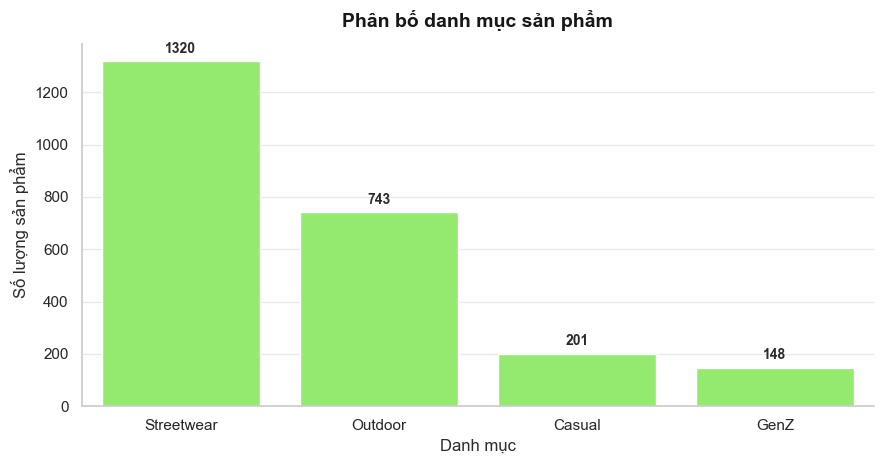

In [286]:
category_counts = count_frame(products["category"], "category")

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=category_counts,
    x="category",
    y="count",
    color=PALETTE["green"],
    ax=ax,
)
clean_axis(ax, xlabel="Danh mục", ylabel="Số lượng sản phẩm", title="Phân bố danh mục sản phẩm")
ax.tick_params(axis="x")
add_bar_labels(ax, fmt="{:.0f}")
plt.tight_layout()
plt.show()


In [287]:
def plot_count_chart(
    df,
    column,
    title,
    xlabel,
    top_n=None,
    color_key="green",
    rotation=0,
    horizontal=False,
    figsize=None,
):
    plot_data = count_frame(df[column], column)
    if top_n is not None:
        plot_data = plot_data.head(top_n)

    if horizontal:
        fig, ax = plt.subplots(figsize=figsize or (10, 5.6))
        sns.barplot(
            data=plot_data,
            y=column,
            x="count",
            color=PALETTE[color_key],
            ax=ax,
        )
        clean_axis(ax, xlabel="Số lượng", ylabel=xlabel, title=title)
        add_hbar_labels(ax, fmt="{:.0f}")
    else:
        fig, ax = plt.subplots(figsize=figsize or (9, 4.8))
        sns.barplot(
            data=plot_data,
            x=column,
            y="count",
            color=PALETTE[color_key],
            ax=ax,
        )
        clean_axis(ax, xlabel=xlabel, ylabel="Số lượng", title=title)
        ax.tick_params(axis="x", rotation=rotation)
        add_bar_labels(ax, fmt="{:.0f}")

    plt.tight_layout()
    plt.show()


#### Segment sản phẩm phân bố như thế nào?


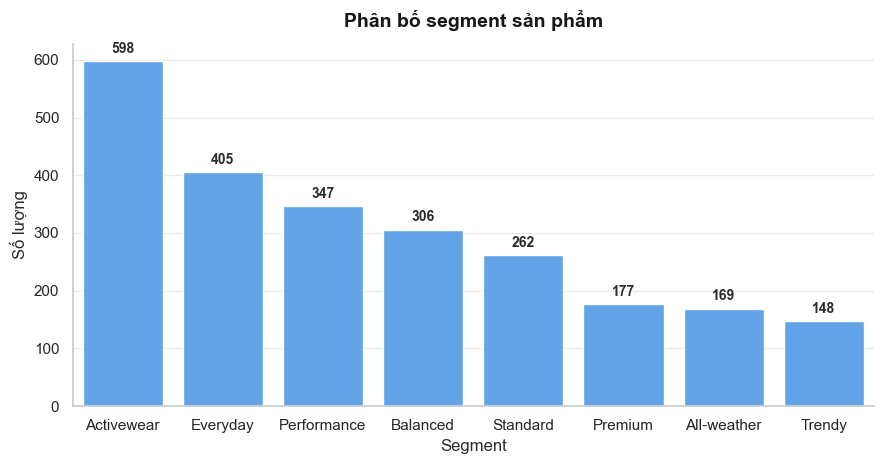

In [288]:
plot_count_chart(
    products,
    "segment",
    "Phân bố segment sản phẩm",
    "Segment",
    color_key="info_blue",
)


#### Khách hàng đến từ những thành phố nào?



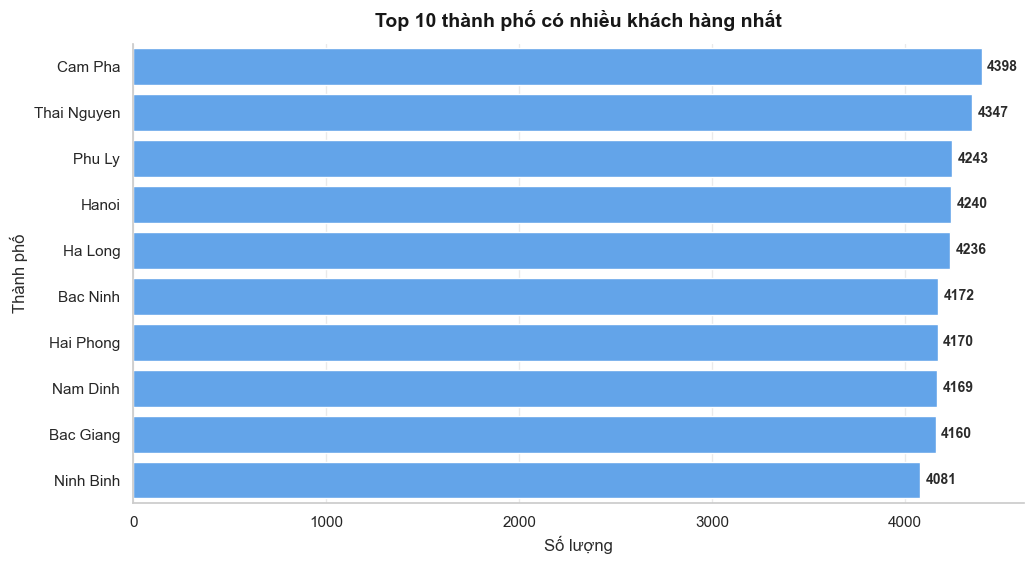

In [289]:
plot_count_chart(
    customers,
    "city",
    "Top 10 thành phố có nhiều khách hàng nhất",
    "Thành phố",
    top_n=10,
    color_key="info_blue",
    horizontal=True,
    figsize=(10.5, 5.8),
)


#### Giới tính của khách hàng phân bố ra sao?



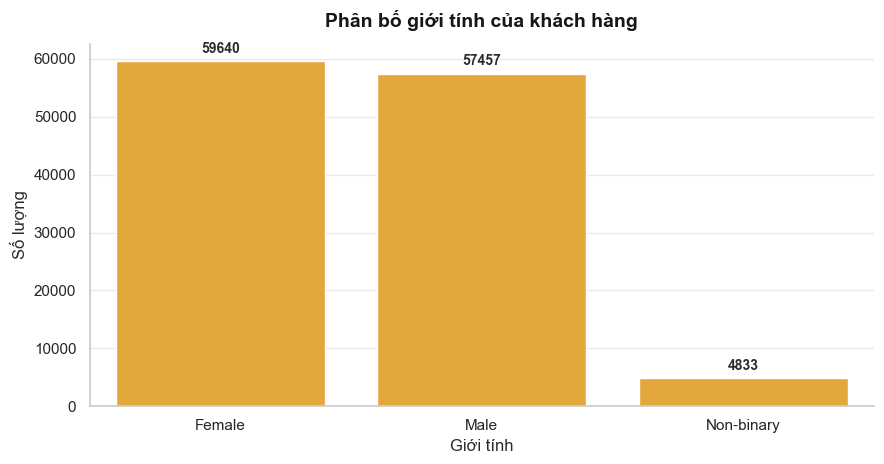

In [290]:
plot_count_chart(
    customers,
    "gender",
    "Phân bố giới tính của khách hàng",
    "Giới tính",
    color_key="warning",
)


#### Nhóm tuổi nào phổ biến hơn?


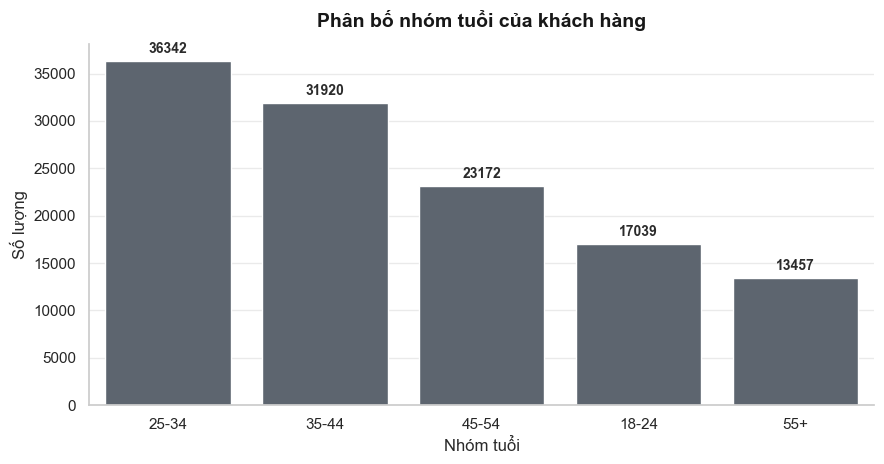

In [291]:
plot_count_chart(
    customers,
    "age_group",
    "Phân bố nhóm tuổi của khách hàng",
    "Nhóm tuổi",
    color_key="base_bar",
)


#### Trạng thái đơn hàng nào xuất hiện nhiều?


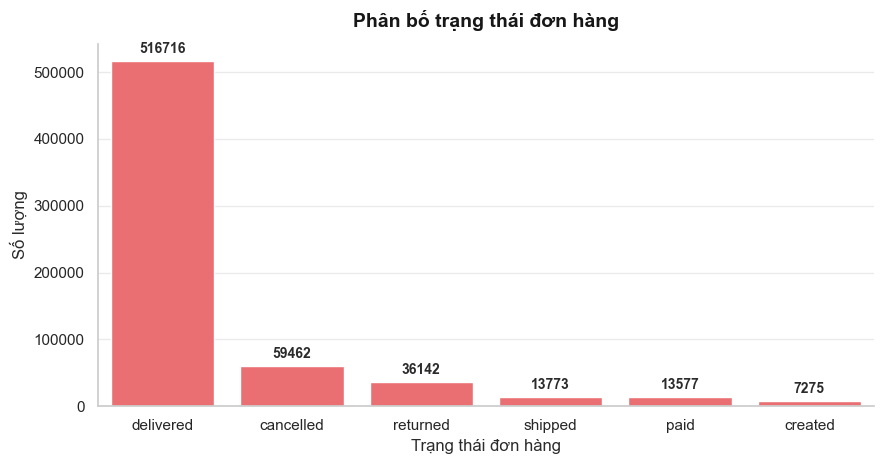

In [292]:
plot_count_chart(
    orders,
    "order_status",
    "Phân bố trạng thái đơn hàng",
    "Trạng thái đơn hàng",
    color_key="risk_red",
)


#### Phương thức thanh toán nào được ghi nhận?


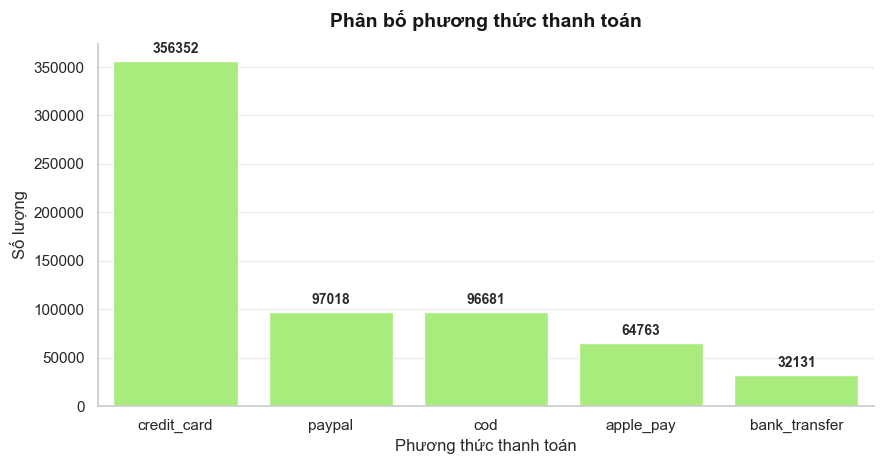

In [293]:
plot_count_chart(
    orders,
    "payment_method",
    "Phân bố phương thức thanh toán",
    "Phương thức thanh toán",
    color_key="lime_green",
)


#### Nguồn đơn hàng đến từ đâu?


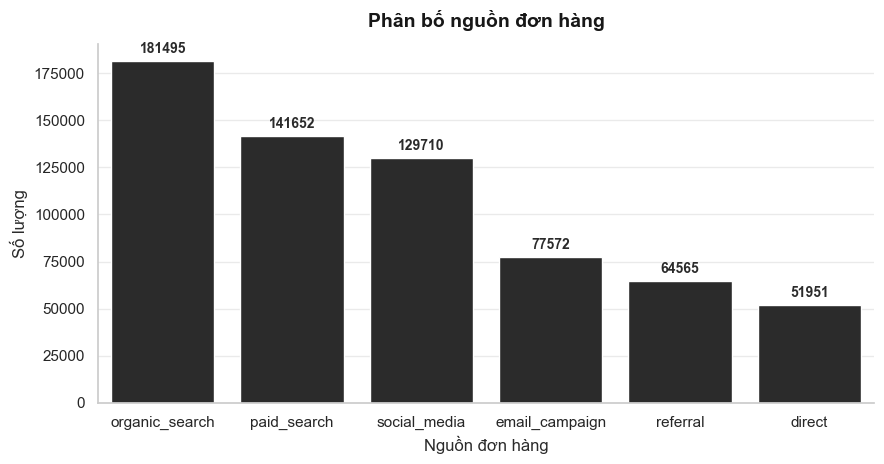

In [294]:
plot_count_chart(
    orders,
    "order_source",
    "Phân bố nguồn đơn hàng",
    "Nguồn đơn hàng",
    color_key="dark_gray",
)


#### Promotion mix nhìn nhanh ra sao?


,business_meaning,null_count,null_rate
applicable_category,Null = áp dụng tất cả,40,0.8
promo_channel,Không có null,0,0.0


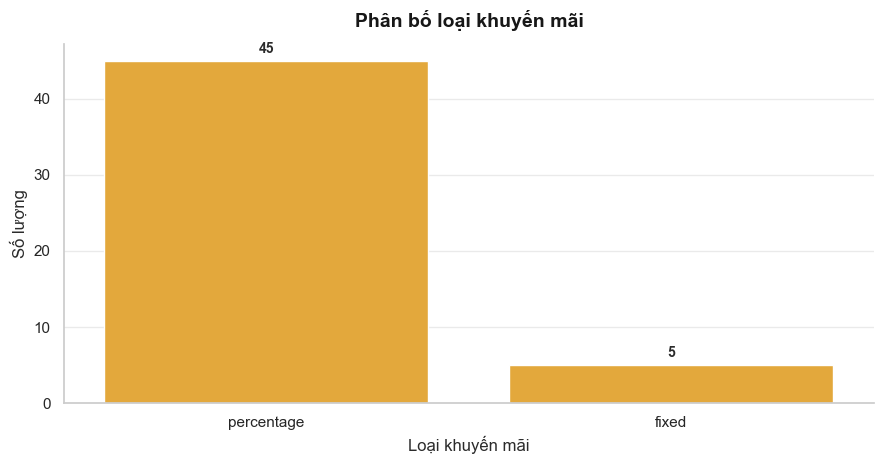

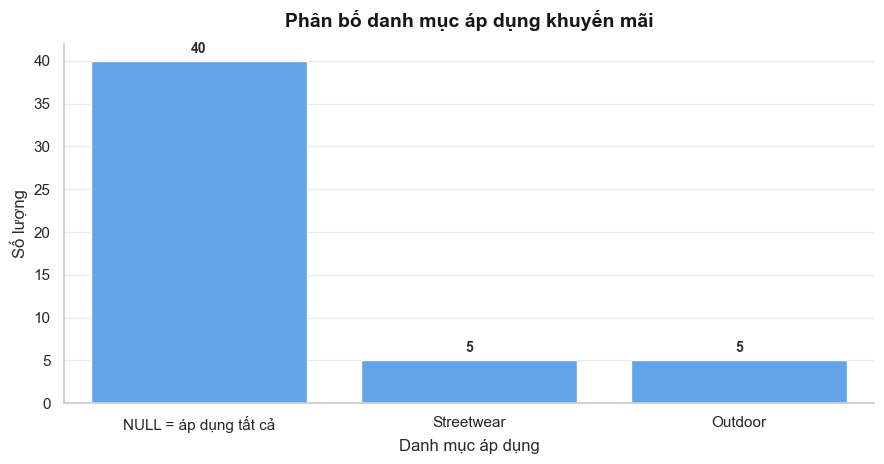

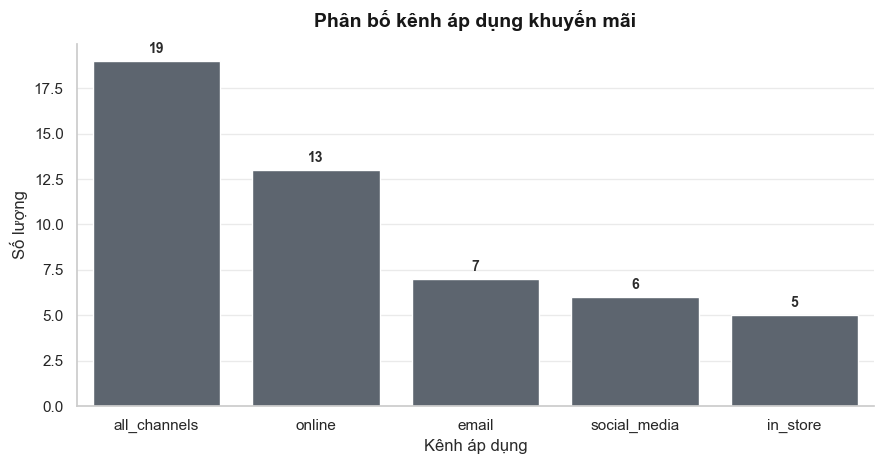

In [295]:
promotion_null_check = pd.DataFrame({
    "business_meaning": ["Null = áp dụng tất cả", "Không có null"],
    "null_count": promotions[["applicable_category", "promo_channel"]].isna().sum().values,
    "null_rate": promotions[["applicable_category", "promo_channel"]].isna().mean().values,
}, index=["applicable_category", "promo_channel"])
display(promotion_null_check)

promotions_glance = promotions.assign(
    applicable_category_display=promotions["applicable_category"].where(
        promotions["applicable_category"].notna(),
        "NULL = áp dụng tất cả"
    )
)

plot_count_chart(
    promotions_glance,
    "promo_type",
    "Phân bố loại khuyến mãi",
    "Loại khuyến mãi",
    color_key="warning",
)

plot_count_chart(
    promotions_glance,
    "applicable_category_display",
    "Phân bố danh mục áp dụng khuyến mãi",
    "Danh mục áp dụng",
    color_key="info_blue",
)

plot_count_chart(
    promotions,
    "promo_channel",
    "Phân bố kênh áp dụng khuyến mãi",
    "Kênh áp dụng",
    color_key="base_bar",
)


### Nhận xét nhanh về dữ liệu

Trước khi phân tích, một số đặc điểm cấu trúc cần ghi nhớ vì ảnh hưởng trực tiếp đến cách đọc insight:

- **Sản phẩm** nghiêng mạnh về `Streetwear` — danh mục này sẽ chi phối phần lớn doanh thu và cần được phân tích riêng về hành vi khách hàng.
- **Khách hàng** phân tán rộng theo thành phố — không có "thị trường trọng điểm" hiển nhiên, nhưng cũng đồng nghĩa tăng trưởng không bị kẹt tại một địa bàn.
- **Order status, payment method, order source** đều đa dạng — cần tách rõ đơn hoàn tất, pipeline mở và hành vi thanh toán từ sớm để tránh làm lệch KPI.
- **Bảng `promotions`** có `null` mang ý nghĩa nghiệp vụ (`null = áp dụng cho tất cả`) — không nên vội xử lý `null` như lỗi dữ liệu.

## Kiểm tra chất lượng dữ liệu

Phần này không audit toàn bộ dataset mà tập trung vào **ba assumption cốt lõi** — nếu hiểu nhầm bất kỳ điểm nào, toàn bộ KPI và phân tích khách hàng phía sau sẽ sai từ nền:

1. **Scope đơn hàng:** Trạng thái nào đi vào baseline hoàn tất, trạng thái nào chỉ là pipeline mở hoặc thất thoát vận hành?
2. **Inventory:** Bảng snapshot có đủ nhất quán để hỗ trợ diễn giải vận hành và mùa vụ không?
3. **Promotions:** Logic discount attribution có đáng tin ở cấp tổng hợp để phân tích discount dependency của khách hàng không?

### 1. Kiểm tra tính nhất quán giữa trạng thái đơn hàng và bảng vận hành

**Lý do kiểm tra:** Scope đơn hàng ảnh hưởng trực tiếp đến cả doanh thu lẫn hành vi khách hàng. Nếu trộn lẫn đơn hoàn tất với pipeline mở, RFM và cohort analysis phía sau sẽ sai.

Logic kiểm tra:
- `shipped`, `delivered`, `returned` → phải có record trong `shipments`.
- `returned` → phải tiếp tục có record trong `returns`.
- Mismatch nếu có → xác định lỗi hệ thống hay độ trễ đồng bộ cuối kỳ.

In [296]:
shipment_status = ["shipped", "delivered", "returned"]

orders_check = orders.copy()
shipments_check = shipments.copy()

target_orders = orders_check.loc[
    orders_check["order_status"].isin(shipment_status),
    ["order_id", "order_status", "order_date"]
].copy()

shipment_order_ids = shipments_check[["order_id"]].drop_duplicates()

shipment_audit = target_orders.merge(
    shipment_order_ids.assign(has_shipment=True),
    on="order_id",
    how="left"
)

shipment_audit["has_shipment"] = shipment_audit["has_shipment"].eq(True)

shipment_summary = (
    shipment_audit
    .groupby("order_status", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        orders_with_shipment_record=("has_shipment", "sum")
    )
)

shipment_summary["orders_without_shipment_record"] = (
    shipment_summary["total_orders"] - shipment_summary["orders_with_shipment_record"]
)

shipment_summary["orders_without_shipment_rate"] = (
    shipment_summary["orders_without_shipment_record"] / shipment_summary["total_orders"]
)

display(shipment_summary)


,order_status,total_orders,orders_with_shipment_record,orders_without_shipment_record,orders_without_shipment_rate
0,delivered,516716,516192,524,0.001014
1,returned,36142,36113,29,0.000802
2,shipped,13773,13762,11,0.000799


In [297]:
returned_orders = orders_check.loc[
    orders_check["order_status"].eq("returned"),
    ["order_id", "order_date"]
].copy()

return_order_ids = returns[["order_id"]].drop_duplicates()

return_audit = returned_orders.merge(
    return_order_ids.assign(has_return=True),
    on="order_id",
    how="left"
)

return_audit["has_return"] = return_audit["has_return"].eq(True)

return_summary = pd.DataFrame({
    "metric": [
        "returned_orders",
        "returned_orders_with_return_record",
        "returned_orders_without_return_record",
        "returned_orders_without_return_record_rate"
    ],
    "value": [
        returned_orders["order_id"].nunique(),
        return_audit["has_return"].sum(),
        (~return_audit["has_return"]).sum(),
        (~return_audit["has_return"]).mean()
    ]
})

display(return_summary)


,metric,value
0,returned_orders,36142.000000
1,returned_orders_with_return_record,36062.000000
2,returned_orders_without_return_record,80.000000
3,returned_orders_without_return_record_rate,0.002213


In [298]:
unmatched_shipment_orders = shipment_audit.loc[
    ~shipment_audit["has_shipment"],
    ["order_id", "order_status", "order_date"]
].copy()

unmatched_return_orders = return_audit.loc[
    ~return_audit["has_return"],
    ["order_id", "order_date"]
].copy()

orders_order_ids = set(orders_check["order_id"].astype(str))
shipment_order_ids_set = set(shipments_check["order_id"].astype(str))
return_order_ids_set = set(returns["order_id"].astype(str))

operational_link_summary = pd.DataFrame({
    "metric": [
        "orders_without_shipment_record",
        "orders_without_shipment_rate",
        "returned_orders_without_return_record",
        "returned_orders_without_return_record_rate",
        "shipment_order_ids_not_in_orders",
        "return_order_ids_not_in_orders"
    ],
    "value": [
        unmatched_shipment_orders["order_id"].nunique(),
        unmatched_shipment_orders["order_id"].nunique() / target_orders["order_id"].nunique(),
        unmatched_return_orders["order_id"].nunique(),
        unmatched_return_orders["order_id"].nunique() / returned_orders["order_id"].nunique(),
        len(shipment_order_ids_set - orders_order_ids),
        len(return_order_ids_set - orders_order_ids)
    ]
})

operational_mismatch_timing = pd.DataFrame({
    "check": [
        "orders_without_shipment_record",
        "returned_orders_without_return_record"
    ],
    "first_order_date": [
        unmatched_shipment_orders["order_date"].min(),
        unmatched_return_orders["order_date"].min()
    ],
    "last_order_date": [
        unmatched_shipment_orders["order_date"].max(),
        unmatched_return_orders["order_date"].max()
    ],
    "distinct_order_dates": [
        unmatched_shipment_orders["order_date"].nunique(),
        unmatched_return_orders["order_date"].nunique()
    ]
})

unmatched_shipment_by_date = (
    unmatched_shipment_orders
    .groupby("order_date", as_index=False)
    .agg(order_count=("order_id", "nunique"))
    .sort_values("order_date", ascending=False)
)

unmatched_return_by_date = (
    unmatched_return_orders
    .groupby("order_date", as_index=False)
    .agg(order_count=("order_id", "nunique"))
    .sort_values("order_date", ascending=False)
)

display(operational_link_summary)
display(operational_mismatch_timing)
display(unmatched_shipment_by_date.head(10))
display(unmatched_return_by_date.head(10))


,metric,value
0,orders_without_shipment_record,564.000000
1,orders_without_shipment_rate,0.000995
2,returned_orders_without_return_record,80.000000
3,returned_orders_without_return_record_rate,0.002213
4,shipment_order_ids_not_in_orders,0.000000
5,return_order_ids_not_in_orders,0.000000


,check,first_order_date,last_order_date,distinct_order_dates
0,orders_without_shipment_record,2022-12-22,2022-12-31,10
1,returned_orders_without_return_record,2022-12-06,2022-12-31,24


,order_date,order_count
9,2022-12-31,68
8,2022-12-30,93
7,2022-12-29,112
6,2022-12-28,121
5,2022-12-27,72
4,2022-12-26,46
3,2022-12-25,25
2,2022-12-24,15
1,2022-12-23,9
0,2022-12-22,3


,order_date,order_count
23,2022-12-31,1
22,2022-12-30,8
21,2022-12-29,7
20,2022-12-28,4
19,2022-12-27,6
18,2022-12-26,4
17,2022-12-25,2
16,2022-12-24,3
15,2022-12-23,5
14,2022-12-22,2


**Kết quả:**

Tỷ lệ mismatch dưới 0.2% ở mọi trạng thái, và phần lớn tập trung vào **cuối tháng 12/2022** — phù hợp với giả thuyết snapshot lệch / ETL lag tại thời điểm dataset được chốt, không phải lỗi nhập liệu diện rộng.

→ **Kết luận:** Có thể yên tâm dùng `delivered + returned` làm completed baseline. Mismatch nhỏ cuối kỳ không ảnh hưởng đến tính tin cậy của phân tích khách hàng phía sau.

### 2. Kiểm tra logic snapshot của inventory

Bảng `inventory` là ảnh chụp cuối tháng — kiểm tra bằng rule vận hành nội tại, không phải mô tả cột.

**Lưu ý khi đọc:** Rule cân bằng tồn kho chỉ áp dụng trên snapshot liền tháng cùng SKU. Tháng bị khuyết không dùng để kết luận balance issue.

In [299]:
inventory_check = inventory.copy()
inventory_check = inventory_check.sort_values(["product_id", "snapshot_date"])

inventory_check["prev_snapshot_date"] = (
    inventory_check
    .groupby("product_id")["snapshot_date"]
    .shift(1)
)
inventory_check["prev_stock_on_hand"] = (
    inventory_check
    .groupby("product_id")["stock_on_hand"]
    .shift(1)
)
inventory_check["month_gap"] = (
    (inventory_check["snapshot_date"].dt.year - inventory_check["prev_snapshot_date"].dt.year) * 12
    + (inventory_check["snapshot_date"].dt.month - inventory_check["prev_snapshot_date"].dt.month)
)
inventory_check["has_contiguous_prev"] = (
    inventory_check["prev_snapshot_date"].notna()
    & inventory_check["month_gap"].eq(1)
)

inventory_check["expected_stock_on_hand"] = (
    inventory_check["prev_stock_on_hand"]
    + inventory_check["units_received"]
    - inventory_check["units_sold"]
)

inventory_check["stock_diff"] = (
    inventory_check["stock_on_hand"] - inventory_check["expected_stock_on_hand"]
)

inventory_check["has_stock_balance_issue"] = (
    inventory_check["has_contiguous_prev"]
    & inventory_check["stock_diff"].ne(0)
)

inventory_balance_summary = pd.DataFrame({
    "metric": [
        "inventory_rows_checked",
        "rows_with_previous_snapshot",
        "rows_with_contiguous_previous_snapshot",
        "rows_skipped_due_to_snapshot_gap",
        "rows_with_stock_balance_issue",
        "stock_balance_issue_rate_on_contiguous_rows",
        "avg_abs_stock_diff_on_contiguous_rows",
        "max_abs_stock_diff_on_contiguous_rows"
    ],
    "value": [
        len(inventory_check),
        inventory_check["prev_snapshot_date"].notna().sum(),
        inventory_check["has_contiguous_prev"].sum(),
        (inventory_check["prev_snapshot_date"].notna() & ~inventory_check["has_contiguous_prev"]).sum(),
        inventory_check["has_stock_balance_issue"].sum(),
        inventory_check.loc[inventory_check["has_contiguous_prev"], "has_stock_balance_issue"].mean(),
        inventory_check.loc[inventory_check["has_contiguous_prev"], "stock_diff"].abs().mean(),
        inventory_check.loc[inventory_check["has_contiguous_prev"], "stock_diff"].abs().max()
    ]
})

display(inventory_balance_summary)

,metric,value
0,inventory_rows_checked,60247.0
1,rows_with_previous_snapshot,58623.0
2,rows_with_contiguous_previous_snapshot,51524.0
3,rows_skipped_due_to_snapshot_gap,7099.0
4,rows_with_stock_balance_issue,0.0
5,stock_balance_issue_rate_on_contiguous_rows,0.0
6,avg_abs_stock_diff_on_contiguous_rows,0.0
7,max_abs_stock_diff_on_contiguous_rows,0.0


In [300]:
inventory_check["has_stockout_flag_issue"] = (
    ((inventory_check["stockout_days"] > 0) & inventory_check["stockout_flag"].eq(0))
    | ((inventory_check["stockout_days"] == 0) & inventory_check["stockout_flag"].eq(1))
)
inventory_check["has_invalid_rate"] = (
    ~inventory_check["fill_rate"].between(0, 1)
    | ~inventory_check["sell_through_rate"].between(0, 1)
)
inventory_check["has_negative_metric"] = (
    inventory_check[["stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply"]]
    .lt(0)
    .any(axis=1)
)
inventory_check["not_month_end_snapshot"] = ~inventory_check["snapshot_date"].dt.is_month_end

inventory_sanity_summary = pd.DataFrame({
    "metric": [
        "rows_with_stockout_flag_issue",
        "rows_with_invalid_rate",
        "rows_with_negative_metric",
        "rows_with_non_month_end_snapshot"
    ],
    "value": [
        inventory_check["has_stockout_flag_issue"].sum(),
        inventory_check["has_invalid_rate"].sum(),
        inventory_check["has_negative_metric"].sum(),
        inventory_check["not_month_end_snapshot"].sum()
    ]
})

display(inventory_sanity_summary)

display(
    inventory_check[
        inventory_check["has_stockout_flag_issue"]
        | inventory_check["has_invalid_rate"]
        | inventory_check["has_negative_metric"]
        | inventory_check["not_month_end_snapshot"]
    ][
        [
            "snapshot_date",
            "product_id",
            "product_name",
            "category",
            "stock_on_hand",
            "units_received",
            "units_sold",
            "stockout_days",
            "stockout_flag",
            "days_of_supply",
            "fill_rate",
            "sell_through_rate",
            "has_stockout_flag_issue",
            "has_invalid_rate",
            "has_negative_metric",
            "not_month_end_snapshot"
        ]
    ]
    .sort_values(["snapshot_date", "product_id"])
    .head(30)
)

,metric,value
0,rows_with_stockout_flag_issue,0
1,rows_with_invalid_rate,0
2,rows_with_negative_metric,0
3,rows_with_non_month_end_snapshot,0


,snapshot_date,product_id,product_name,category,stock_on_hand,units_received,units_sold,stockout_days,stockout_flag,days_of_supply,fill_rate,sell_through_rate,has_stockout_flag_issue,has_invalid_rate,has_negative_metric,not_month_end_snapshot


**Kết quả:**

51,524 cặp snapshot liền tháng đều vượt qua rule cân bằng tồn kho (`stock_balance_issue_rate = 0.0`). Các flag và rate đều trong range hợp lệ, không có giá trị âm bất thường.

→ **Kết luận:** Bảng `inventory` đủ tin để hỗ trợ nhận xét về vận hành và mùa vụ — đặc biệt khi phân tích xem nhóm sản phẩm nào đang gây stockout hay overstock ảnh hưởng đến trải nghiệm khách hàng.

### 3. Kiểm tra logic discount và promotion attribution

**Lý do kiểm tra:** `discount_amount` là đầu vào trực tiếp cho phân tích **discount dependency** của khách hàng ở Lớp 2 — nếu mã promo bị gắn sai hoặc ngoài campaign window, kết quả phân tích nhóm khách hàng phụ thuộc khuyến mãi sẽ bị lệch.

In [301]:
promo_ref_1 = promotions.add_prefix("promo_").rename(columns={"promo_promo_id": "promo_id"})
promo_ref_2 = promotions.add_prefix("promo2_").rename(columns={"promo2_promo_id": "promo_id_2"})

promo_check = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)
promo_check = promo_check.merge(promo_ref_1, on="promo_id", how="left")
promo_check = promo_check.merge(promo_ref_2, on="promo_id_2", how="left")

promo_check["has_promo_1"] = promo_check["promo_id"].notna()
promo_check["has_promo_2"] = promo_check["promo_id_2"].notna()
promo_check["has_any_promo"] = promo_check["has_promo_1"] | promo_check["has_promo_2"]
promo_check["has_two_promos"] = promo_check["has_promo_1"] & promo_check["has_promo_2"]

promo_check["invalid_promo_1_ref"] = promo_check["has_promo_1"] & promo_check["promo_promo_name"].isna()
promo_check["invalid_promo_2_ref"] = promo_check["has_promo_2"] & promo_check["promo2_promo_name"].isna()

promo_check["promo_1_outside_window"] = (
    promo_check["has_promo_1"]
    & ~promo_check["invalid_promo_1_ref"]
    & ~promo_check["order_date"].between(promo_check["promo_start_date"], promo_check["promo_end_date"])
)
promo_check["promo_2_outside_window"] = (
    promo_check["has_promo_2"]
    & ~promo_check["invalid_promo_2_ref"]
    & ~promo_check["order_date"].between(promo_check["promo2_start_date"], promo_check["promo2_end_date"])
)

promo_check["has_non_stackable_conflict"] = (
    promo_check["has_two_promos"]
    & (
        promo_check["promo_stackable_flag"].eq(0)
        | promo_check["promo2_stackable_flag"].eq(0)
    )
)

promotion_quality_summary = pd.DataFrame({
    "metric": [
        "order_item_rows_with_any_promo",
        "order_item_rows_with_two_promos",
        "invalid_promo_1_refs",
        "invalid_promo_2_refs",
        "promo_usage_outside_window_rows",
        "non_stackable_rows_with_two_promos"
    ],
    "value": [
        promo_check["has_any_promo"].sum(),
        promo_check["has_two_promos"].sum(),
        promo_check["invalid_promo_1_ref"].sum(),
        promo_check["invalid_promo_2_ref"].sum(),
        (promo_check["promo_1_outside_window"] | promo_check["promo_2_outside_window"]).sum(),
        promo_check["has_non_stackable_conflict"].sum()
    ]
})

promo_usage_long = pd.concat([
    promo_check.loc[promo_check["has_promo_1"], ["promo_id"]],
    promo_check.loc[promo_check["has_promo_2"], ["promo_id_2"]].rename(columns={"promo_id_2": "promo_id"})
], ignore_index=True)

top_used_promotions = (
    promo_usage_long.groupby("promo_id", as_index=False)
    .size()
    .rename(columns={"size": "promo_usage_rows"})
    .merge(
        promotions[["promo_id", "promo_name", "promo_type", "promo_channel", "stackable_flag"]],
        on="promo_id",
        how="left"
    )
    .sort_values("promo_usage_rows", ascending=False)
    .head(10)
)

display(promotion_quality_summary)
display(top_used_promotions)


,metric,value
0,order_item_rows_with_any_promo,276316
1,order_item_rows_with_two_promos,206
2,invalid_promo_1_refs,0
3,invalid_promo_2_refs,0
4,promo_usage_outside_window_rows,0
5,non_stackable_rows_with_two_promos,206


,promo_id,promo_usage_rows,promo_name,promo_type,promo_channel,stackable_flag
13,PROMO-0014,11451,Year-End Sale 2015,percentage,all_channels,1
9,PROMO-0010,11345,Year-End Sale 2014,percentage,all_channels,0
3,PROMO-0004,11126,Year-End Sale 2013,percentage,all_channels,0
19,PROMO-0020,10121,Year-End Sale 2016,percentage,all_channels,0
10,PROMO-0011,9594,Spring Sale 2015,percentage,all_channels,1
6,PROMO-0007,9373,Spring Sale 2014,percentage,email,1
20,PROMO-0021,8966,Spring Sale 2017,percentage,all_channels,0
16,PROMO-0017,8808,Spring Sale 2016,percentage,all_channels,0
0,PROMO-0001,8523,Spring Sale 2013,percentage,email,1
23,PROMO-0024,8205,Year-End Sale 2017,percentage,all_channels,0


**Kết quả:**

- `promo_id` trong `order_items` map đầy đủ về bảng `promotions` — không có mã khuyến mãi lạ.
- Không có row nào dùng promo ngoài campaign window.
- 206 row có 2 promo đồng thời với ít nhất một promo `non-stackable` — quy mô quá nhỏ để làm lệch phân tích discount tổng hợp.

→ **Kết luận:** `discount_amount` đủ đáng tin ở cấp tổng hợp. Có thể dùng để phân tích discount rate theo khách hàng và nhóm sản phẩm ở các lớp tiếp theo.

#### Tổng kết kiểm tra chất lượng dữ liệu

| Hạng mục | Kết luận |
|---|---|
| Scope đơn hàng | `Completed baseline = delivered + returned`; `Open pipeline = shipped + paid + created`; `Cancelled` = loại trừ |
| Mismatch vận hành | Snapshot lag cuối kỳ, không ảnh hưởng đến baseline phân tích |
| Bảng inventory | Vượt qua toàn bộ rule consistency; đủ tin cho nhận xét vận hành |
| Bảng promotions | Sạch về mã và thời gian; 206 edge case không đủ lớn để cản trở phân tích discount |

Với các assumption này đã được khóa, phần EDA phía dưới có thể tập trung đúng vào **chất lượng doanh thu → hành vi khách hàng → chiến lược marketing** mà không lo lẫn giữa pipeline và completed baseline.

# EDA

Phần EDA đi theo logic tổng thể `Tác động kinh doanh -> Insight khách hàng -> Hành động marketing`.

Lớp đầu tiên bên dưới tập trung vào `chất lượng doanh thu và áp lực thu tiền`: doanh nghiệp tạo ra bao nhiêu doanh thu, giữ lại được bao nhiêu sau chiết khấu và giá vốn, rồi chất lượng đó còn bị kéo bởi hoàn tiền và trả góp như thế nào.

## Lớp 1 - Chất lượng doanh thu và áp lực thu tiền

- Mục tiêu đọc theo chuỗi `tạo doanh thu -> giữ lại biên lợi nhuận -> áp lực hậu bán hàng -> áp lực thu tiền chậm -> mùa vụ`.
- Main analysis chỉ dùng `baseline hoàn tất = delivered + returned`; các trạng thái `shipped`, `paid`, `created` chỉ dùng để khóa scope và ghi chú pipeline.

### Scope phân tích

**Mục tiêu:** Xác nhận rõ bao nhiêu phần trăm doanh thu nằm ở từng nhóm trạng thái, trước khi đọc bất kỳ KPI nào.



In [302]:
completed_status = ['delivered', 'returned']
open_pipeline_status = ['shipped', 'paid', 'created']
excluded_status = ['cancelled']
status_order = ['created', 'paid', 'shipped', 'delivered', 'returned', 'cancelled']
status_scope_map = {
    'delivered': 'Baseline hoàn tất',
    'returned': 'Baseline hoàn tất',
    'shipped': 'Pipeline mở',
    'paid': 'Pipeline mở',
    'created': 'Pipeline mở',
    'cancelled': 'Loại trừ / thất thoát',
}
product_cols = ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']


def build_order_line_fact(orders_df, order_items_df, products_df):
    order_line_fact = (
        orders_df
        .merge(order_items_df, on='order_id', how='inner')
        .merge(products_df[product_cols], on='product_id', how='left')
        .rename(columns={'cogs': 'product_unit_cogs'})
    )
    order_line_fact['gross_line_sales'] = order_line_fact['quantity'] * order_line_fact['unit_price']
    order_line_fact['line_revenue'] = order_line_fact['gross_line_sales'] - order_line_fact['discount_amount']
    order_line_fact['line_cogs'] = order_line_fact['quantity'] * order_line_fact['product_unit_cogs']
    order_line_fact['line_gross_profit'] = order_line_fact['line_revenue'] - order_line_fact['line_cogs']
    return order_line_fact


all_order_line_fact = build_order_line_fact(orders, order_items, products)
all_order_line_fact['scope_group'] = all_order_line_fact['order_status'].map(status_scope_map).fillna('Khác')


status_revenue_summary = (
    all_order_line_fact.groupby(['order_status', 'scope_group'], as_index=False)
    .agg(
        gross_sales=('gross_line_sales', 'sum'),
        discount_amount=('discount_amount', 'sum'),
        net_revenue=('line_revenue', 'sum'),
    )
)
status_revenue_summary['order_status'] = pd.Categorical(
    status_revenue_summary['order_status'],
    categories=status_order,
    ordered=True,
)
status_revenue_summary = status_revenue_summary.sort_values('order_status').reset_index(drop=True)
status_revenue_summary['net_revenue_share'] = (
    status_revenue_summary['net_revenue'] / status_revenue_summary['net_revenue'].sum()
)

status_revenue_display = status_revenue_summary.rename(
    columns={
        'order_status': 'Trạng thái đơn hàng',
        'scope_group': 'Nhóm scope',
        'gross_sales': 'Doanh thu gộp',
        'discount_amount': 'Chiết khấu',
        'net_revenue': 'Doanh thu thuần',
        'net_revenue_share': 'Tỷ trọng doanh thu thuần',
    }
)

display(
    status_revenue_display.assign(
        **{
            'Doanh thu gộp': lambda df: df['Doanh thu gộp'].map(format_currency),
            'Chiết khấu': lambda df: df['Chiết khấu'].map(format_currency),
            'Doanh thu thuần': lambda df: df['Doanh thu thuần'].map(format_currency),
            'Tỷ trọng doanh thu thuần': lambda df: df['Tỷ trọng doanh thu thuần'].map(format_pct),
        }
    )
)

,Trạng thái đơn hàng,Nhóm scope,Doanh thu gộp,Chiết khấu,Doanh thu thuần,Tỷ trọng doanh thu thuần
0,created,Pipeline mở,"190,652,331","8,817,312","181,835,019",1.16%
1,paid,Pipeline mở,"345,922,855","15,295,759","330,627,096",2.11%
2,shipped,Pipeline mở,"353,376,001","16,097,161","337,278,840",2.15%
3,delivered,Baseline hoàn tất,"13,117,091,360","598,915,403","12,518,175,957",79.83%
4,returned,Baseline hoàn tất,"907,543,032","41,604,316","865,938,716",5.52%
5,cancelled,Loại trừ / thất thoát,"1,515,891,006","68,877,369","1,447,013,637",9.23%


### Dựng bảng fact và bảng tổng hợp

Dữ liệu được tổ chức theo đúng grain trước khi tính KPI, tránh double-count:

- **`order_line_fact`** — grain `1 dòng = 1 SKU trong 1 đơn`; dùng để tính gross sales, discount, COGS, gross profit.
- **`payment_order_level`** — grain `1 dòng = 1 đơn hàng`; tránh phóng đại payment khi join xuống line-item (lệch thực tế **1.09×** nếu join sai).
- **`returns_eda`** — grain `1 dòng = 1 dòng hoàn trả`; lấy riêng từ `returns.csv`, map về sản phẩm bằng `order_id + product_id`.

In [303]:
completed_orders = orders.loc[orders['order_status'].isin(completed_status)].copy()

order_line_fact = all_order_line_fact.loc[
    all_order_line_fact['order_status'].isin(completed_status)
].copy()
order_line_fact['discount_rate'] = (
    order_line_fact['discount_amount'] / order_line_fact['gross_line_sales'].replace(0, np.nan)
)
order_line_fact['line_gross_margin'] = (
    order_line_fact['line_gross_profit'] / order_line_fact['line_revenue'].replace(0, np.nan)
)
order_line_fact['year'] = order_line_fact['order_date'].dt.year
order_line_fact['month'] = order_line_fact['order_date'].dt.month
order_line_fact['month_name'] = order_line_fact['order_date'].dt.strftime('%b')
order_line_fact['year_month'] = order_line_fact['order_date'].dt.to_period('M').dt.to_timestamp()

payment_order_level = (
    payments.loc[payments['order_id'].isin(completed_orders['order_id'])]
    .groupby('order_id', as_index=False)
    .agg(
        payment_value=('payment_value', 'sum'),
        installments=('installments', 'max'),
        payment_method=('payment_method', 'first'),
    )
)

order_payment_eda = completed_orders[['order_id', 'order_date', 'order_status']].merge(
    payment_order_level,
    on='order_id',
    how='left',
)
order_payment_eda['payment_value'] = order_payment_eda['payment_value'].fillna(0)
order_payment_eda['installments'] = order_payment_eda['installments'].fillna(1).clip(lower=1).astype(int)
order_payment_eda['year'] = order_payment_eda['order_date'].dt.year
order_payment_eda['year_month'] = order_payment_eda['order_date'].dt.to_period('M').dt.to_timestamp()
order_payment_eda['is_multi_installment'] = order_payment_eda['installments'].gt(1)
order_payment_eda['estimated_first_period_collection'] = (
    order_payment_eda['payment_value'] / order_payment_eda['installments']
)
order_payment_eda['estimated_deferred_exposure'] = (
    order_payment_eda['payment_value']
    * (order_payment_eda['installments'] - 1)
    / order_payment_eda['installments']
)

returns_eda = returns.loc[returns['order_id'].isin(completed_orders['order_id'])].copy()
returns_eda['return_month'] = returns_eda['return_date'].dt.to_period('M').dt.to_timestamp()

refund_mapping_check = returns_eda.merge(
    order_line_fact[['order_id', 'product_id']].drop_duplicates().assign(has_line_match=True),
    on=['order_id', 'product_id'],
    how='left',
)

refund_mapping_summary = pd.DataFrame(
    {
        'Kiểm tra': [
            'Số dòng hoàn tiền',
            'Số dòng map được theo order_id + product_id',
            'Tỷ lệ map hoàn tiền',
        ],
        'Giá trị': [
            len(refund_mapping_check),
            refund_mapping_check['has_line_match'].eq(True).sum(),
            refund_mapping_check['has_line_match'].eq(True).mean(),
        ],
    }
)

naive_line_level_payment_sum = (
    order_line_fact[['order_id', 'product_id']]
    .merge(payment_order_level[['order_id', 'payment_value']], on='order_id', how='left')['payment_value']
    .sum()
)
true_order_level_payment_sum = payment_order_level['payment_value'].sum()

payment_guardrail = pd.DataFrame(
    {
        'Kiểm tra': [
            'Tổng payment_value ở grain đơn hàng',
            'Tổng payment_value nếu join thẳng xuống line-item',
            'Hệ số phóng đại nếu cộng sai grain',
        ],
        'Giá trị': [
            true_order_level_payment_sum,
            naive_line_level_payment_sum,
            naive_line_level_payment_sum / true_order_level_payment_sum if true_order_level_payment_sum else np.nan,
        ],
    }
)

In [304]:
def aggregate_business(frame: pd.DataFrame, group_key: str) -> pd.DataFrame:
    return (
        frame.groupby(group_key, as_index=False)
        .agg(
            gross_sales=('gross_line_sales', 'sum'),
            discount_amount=('discount_amount', 'sum'),
            net_revenue=('line_revenue', 'sum'),
            cogs=('line_cogs', 'sum'),
            gross_profit=('line_gross_profit', 'sum'),
            order_count=('order_id', pd.Series.nunique),
            customer_count=('customer_id', pd.Series.nunique),
            total_quantity=('quantity', 'sum'),
        )
    )



def add_business_ratios(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['gross_margin'] = df['gross_profit'] / df['net_revenue'].replace(0, np.nan)
    df['discount_rate'] = df['discount_amount'] / df['gross_sales'].replace(0, np.nan)
    df['aov'] = df['net_revenue'] / df['order_count'].replace(0, np.nan)
    df['units_per_order'] = df['total_quantity'] / df['order_count'].replace(0, np.nan)
    return df


monthly_business = aggregate_business(order_line_fact, 'year_month').sort_values('year_month').reset_index(drop=True)
monthly_business = add_business_ratios(monthly_business)
monthly_business['year'] = monthly_business['year_month'].dt.year
monthly_business['month'] = monthly_business['year_month'].dt.month
monthly_business['month_name'] = monthly_business['year_month'].dt.strftime('%b')
monthly_business['month_label'] = 'T' + monthly_business['month'].astype(str)

yearly_business = aggregate_business(order_line_fact, 'year').sort_values('year').reset_index(drop=True)
yearly_business = add_business_ratios(yearly_business)

calendar_month_profile = (
    monthly_business.groupby(['month', 'month_name'], as_index=False)
    .agg(
        avg_net_revenue=('net_revenue', 'mean'),
        avg_gross_margin=('gross_margin', 'mean'),
    )
    .sort_values('month')
)
calendar_month_profile['month_label'] = 'T' + calendar_month_profile['month'].astype(str)

installment_mix = (
    order_payment_eda.groupby('installments', as_index=False)
    .agg(
        payment_value=('payment_value', 'sum'),
        order_count=('order_id', pd.Series.nunique),
        estimated_first_period_collection=('estimated_first_period_collection', 'sum'),
        estimated_deferred_exposure=('estimated_deferred_exposure', 'sum'),
    )
    .sort_values('installments')
)
installment_mix['payment_value_share'] = installment_mix['payment_value'] / installment_mix['payment_value'].sum()
installment_mix['deferred_exposure_ratio'] = (
    installment_mix['estimated_deferred_exposure'] / installment_mix['payment_value'].replace(0, np.nan)
)
installment_mix['installment_label'] = installment_mix['installments'].astype(str) + ' kỳ'

total_refund_amount = returns_eda['refund_amount'].sum()
total_payment_value = order_payment_eda['payment_value'].sum()
multi_installment_payment_share = (
    order_payment_eda.loc[order_payment_eda['is_multi_installment'], 'payment_value'].sum() / total_payment_value
)
overall_deferred_exposure_ratio = (
    order_payment_eda['estimated_deferred_exposure'].sum() / total_payment_value
)

revenue_quality_mix = pd.DataFrame(
    {
        'component': ['Chiết khấu', 'Giá vốn', 'Lợi nhuận gộp'],
        'amount': [
            order_line_fact['discount_amount'].sum(),
            order_line_fact['line_cogs'].sum(),
            order_line_fact['line_gross_profit'].sum(),
        ],
        'color': [PALETTE['warning'], PALETTE['base_bar'], PALETTE['green']],
    }
)
revenue_quality_mix['per_100_gross_sales'] = (
    revenue_quality_mix['amount'] / order_line_fact['gross_line_sales'].sum() * 100
)

analysis_start = completed_orders['order_date'].min()
analysis_end = completed_orders['order_date'].max()
analysis_years = yearly_business['year'].nunique()

### Data Validation — Khóa độ tin cậy metric nền

Trước khi đọc doanh thu, margin và refund, các metric tính từ transaction có đủ tin cậy để dùng làm baseline hay không?




In [305]:
daily_transaction_recon = (
    order_line_fact.groupby('order_date', as_index=False)
    .agg(
        txn_net_revenue=('line_revenue', 'sum'),
        txn_cogs=('line_cogs', 'sum'),
    )
)

sales_recon = sales.rename(
    columns={
        'Date': 'order_date',
        'Revenue': 'sales_net_revenue',
        'COGS': 'sales_cogs',
    }
).copy()

daily_reconciliation = (
    sales_recon
    .merge(daily_transaction_recon, on='order_date', how='outer')
    .sort_values('order_date')
)
for col in ['sales_net_revenue', 'sales_cogs', 'txn_net_revenue', 'txn_cogs']:
    daily_reconciliation[col] = daily_reconciliation[col].fillna(0)

daily_reconciliation['revenue_diff'] = (
    daily_reconciliation['txn_net_revenue'] - daily_reconciliation['sales_net_revenue']
)
daily_reconciliation['cogs_diff'] = (
    daily_reconciliation['txn_cogs'] - daily_reconciliation['sales_cogs']
)

reconciliation_summary = pd.DataFrame(
    {
        'Kiểm tra': [
            'Tổng doanh thu thuần từ transaction',
            'Tổng doanh thu từ sales.csv',
            'Chênh lệch tổng doanh thu',
            'Tổng giá vốn từ transaction',
            'Tổng giá vốn từ sales.csv',
            'Chênh lệch tổng giá vốn',
            'Chênh lệch doanh thu theo ngày lớn nhất',
            'Chênh lệch giá vốn theo ngày lớn nhất',
        ],
        'Giá trị': [
            format_currency(daily_reconciliation['txn_net_revenue'].sum()),
            format_currency(daily_reconciliation['sales_net_revenue'].sum()),
            format_currency(daily_reconciliation['revenue_diff'].sum()),
            format_currency(daily_reconciliation['txn_cogs'].sum()),
            format_currency(daily_reconciliation['sales_cogs'].sum()),
            format_currency(daily_reconciliation['cogs_diff'].sum()),
            format_currency(daily_reconciliation['revenue_diff'].abs().max()),
            format_currency(daily_reconciliation['cogs_diff'].abs().max()),
        ],
    }
)

payment_guardrail_display = payment_guardrail.copy()
payment_guardrail_display['Giá trị'] = payment_guardrail_display.apply(
    lambda row: f"{row['Giá trị']:.2f}x" if 'Hệ số' in row['Kiểm tra'] else format_currency(row['Giá trị']),
    axis=1,
)

refund_mapping_display = refund_mapping_summary.copy()
refund_mapping_display['Giá trị'] = refund_mapping_display.apply(
    lambda row: format_pct(row['Giá trị']) if 'Tỷ lệ' in row['Kiểm tra'] else format_number(row['Giá trị']),
    axis=1,
)

print('Baseline hoàn tất:', ', '.join(completed_status))
if np.isclose(daily_reconciliation['revenue_diff'].sum(), 0) and np.isclose(daily_reconciliation['cogs_diff'].sum(), 0):
    print('Kết luận đối soát: transaction-derived metrics khớp sát với sales.csv.')
else:
    print('Kết luận đối soát: transaction table dùng để phân tích driver; sales.csv giữ vai trò cross-check tổng.')

display(reconciliation_summary)
display(payment_guardrail_display)
display(refund_mapping_display)

Baseline hoàn tất: delivered, returned
Kết luận đối soát: transaction table dùng để phân tích driver; sales.csv giữ vai trò cross-check tổng.


,Kiểm tra,Giá trị
0,Tổng doanh thu thuần từ transaction,"13,384,114,673"
1,Tổng doanh thu từ sales.csv,"16,430,476,586"
2,Chênh lệch tổng doanh thu,"-3,046,361,913"
3,Tổng giá vốn từ transaction,"12,086,960,427"
4,Tổng giá vốn từ sales.csv,"14,163,450,519"
5,Chênh lệch tổng giá vốn,"-2,076,490,092"
6,Chênh lệch doanh thu theo ngày lớn nhất,"4,422,572"
7,Chênh lệch giá vốn theo ngày lớn nhất,"2,514,835"


,Kiểm tra,Giá trị
0,Tổng payment_value ở grain đơn hàng,"13,384,114,673"
1,Tổng payment_value nếu join thẳng xuống line-item,"14,603,614,491"
2,Hệ số phóng đại nếu cộng sai grain,1.09x


,Kiểm tra,Giá trị
0,Số dòng hoàn tiền,"39,939"
1,Số dòng map được theo order_id + product_id,"39,939"
2,Tỷ lệ map hoàn tiền,100.00%


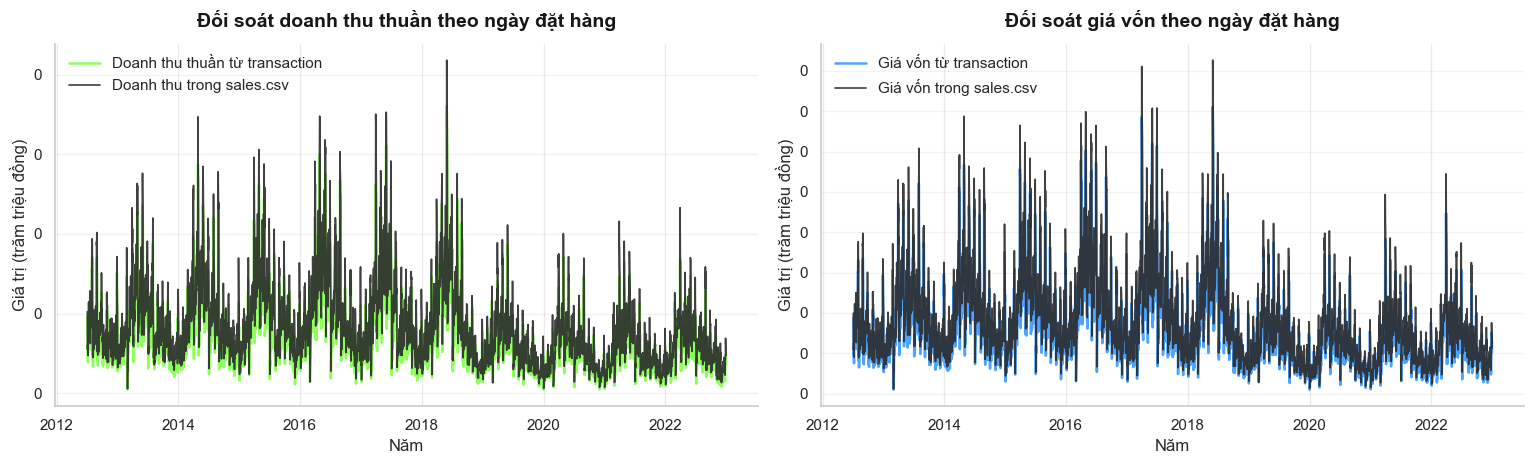

In [306]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.8), sharex=True)

axes[0].plot(
    daily_reconciliation['order_date'],
    daily_reconciliation['txn_net_revenue'],
    color=PALETTE['green'],
    linewidth=1.8,
    label='Doanh thu thuần từ transaction',
)
axes[0].plot(
    daily_reconciliation['order_date'],
    daily_reconciliation['sales_net_revenue'],
    color=PALETTE['dark_gray'],
    linewidth=1.2,
    alpha=0.9,
    label='Doanh thu trong sales.csv',
)
clean_axis(
    axes[0],
    xlabel='Năm',
    ylabel='Giá trị (trăm triệu đồng)',
    title='Đối soát doanh thu thuần theo ngày đặt hàng',
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(frameon=False, loc='upper left')

axes[1].plot(
    daily_reconciliation['order_date'],
    daily_reconciliation['txn_cogs'],
    color=PALETTE['info_blue'],
    linewidth=1.8,
    label='Giá vốn từ transaction',
)
axes[1].plot(
    daily_reconciliation['order_date'],
    daily_reconciliation['sales_cogs'],
    color=PALETTE['dark_gray'],
    linewidth=1.2,
    alpha=0.9,
    label='Giá vốn trong sales.csv',
)
clean_axis(
    axes[1],
    xlabel='Năm',
    ylabel='Giá trị (trăm triệu đồng)',
    title='Đối soát giá vốn theo ngày đặt hàng',
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

- Doanh thu thuần tính từ transaction đạt **13.38 tỷ**, trong khi `sales.csv` ghi nhận **16.43 tỷ**, chênh lệch khoảng **3.05 tỷ** hay **18.5%**. Giá vốn cũng lệch theo cùng chiều: transaction cho **12.09 tỷ** so với **14.16 tỷ** từ `sales.csv`.

- Tuy nhiên, điểm đáng chú ý là chênh lệch lớn nhất ở cấp ngày chỉ khoảng **4.42 triệu** với doanh thu và **2.51 triệu** với giá vốn, nghĩa là hình dạng theo thời gian của hai nguồn vẫn bám sát nhau. Chênh lệch tổng nhiều khả năng đến từ việc `sales.csv` bao quát rộng hơn completed baseline, không phải do lỗi dữ liệu.

→ Transaction table dùng để phân tích driver theo khách hàng và SKU; `sales.csv` giữ vai trò cross-check tổng hợp.

- Nếu join `payment_value` thẳng xuống line-item rồi cộng, con số sẽ bị thổi lên **14.60 tỷ** thay vì đúng **13.38 tỷ** lệch **1.09 lần**. Mọi phân tích installment trong notebook này đều giữ grain đơn hàng để tránh lỗi này.

- Toàn bộ **39,939 dòng** hoàn tiền từ `returns.csv` đều map được về `order_id + product_id`, tỷ lệ khớp **100%**. Điều này đảm bảo refund amount phản ánh đúng sản phẩm thực tế bị trả, phục vụ cho phân tích return rate theo danh mục và khách hàng ở Lớp 2.


### Chart 1 — KPI Snapshot toàn kỳ

**Câu hỏi business:**  
Doanh nghiệp đang đứng ở đâu về quy mô, chất lượng doanh thu và áp lực thu tiền trong giai đoạn phân tích **2012-07-04 đến 2022-12-31**?


In [307]:
kpi_snapshot = pd.DataFrame(
    {
        'Chỉ số': [
            'Doanh thu thuần',
            'Lợi nhuận gộp',
            'Biên lợi nhuận gộp',
            'Tỷ lệ chiết khấu',
            'Giá trị hoàn tiền',
            'Tỷ trọng giá trị thanh toán trả góp nhiều kỳ',
        ],
        'Giá trị': [
            format_currency(order_line_fact['line_revenue'].sum()),
            format_currency(order_line_fact['line_gross_profit'].sum()),
            format_pct(order_line_fact['line_gross_profit'].sum() / order_line_fact['line_revenue'].sum()),
            format_pct(order_line_fact['discount_amount'].sum() / order_line_fact['gross_line_sales'].sum()),
            format_currency(total_refund_amount),
            format_pct(multi_installment_payment_share),
        ],
    }
)

print('Khoảng thời gian phân tích:', analysis_start.strftime('%Y-%m-%d'), '->', analysis_end.strftime('%Y-%m-%d'))
print('Số năm dữ liệu trong baseline hoàn tất:', analysis_years)
display(kpi_snapshot)

Khoảng thời gian phân tích: 2012-07-04 -> 2022-12-31
Số năm dữ liệu trong baseline hoàn tất: 11


,Chỉ số,Giá trị
0,Doanh thu thuần,"13,384,114,673"
1,Lợi nhuận gộp,"1,297,154,245"
2,Biên lợi nhuận gộp,9.69%
3,Tỷ lệ chiết khấu,4.57%
4,Giá trị hoàn tiền,"510,598,507"
5,Tỷ trọng giá trị thanh toán trả góp nhiều kỳ,60.38%


- Doanh thu thuần lũy kế đạt **13.38 tỷ đồng** trong hơn 10 năm. Nhưng sau khi trừ **12.09 tỷ** giá vốn, lợi nhuận gộp chỉ còn **1.30 tỷ**, tức cứ bán ra **10 đồng doanh thu thuần** thì chỉ giữ lại chưa đến **1 đồng lợi nhuận gộp**. Tỷ lệ chiết khấu **4.57%** trên gross sales đã cắt đi **640.5 triệu** trước khi doanh nghiệp bước vào bài toán giá vốn.

- Ở phía sau bán hàng, **510.6 triệu** hoàn tiền tương đương **3.8% doanh thu thuần**, phát sinh sau khi doanh thu đã được ghi nhận. Và **60.38%** giá trị thanh toán đang nằm ở đơn nhiều kỳ, nghĩa là chưa đến một nửa tiền hàng thực sự về tay doanh nghiệp ngay tại thời điểm giao dịch.

- **Nhìn tổng thể:** Với biên gộp chỉ **9.69%**, chỉ cần tỷ lệ hoàn tiền tăng thêm vài điểm phần trăm hoặc cơ cấu đơn nhiều kỳ tiếp tục nở rộng, phần lợi nhuận còn lại sẽ bị bào mòn rất nhanh. Tăng thêm đơn hàng trong bối cảnh này chưa chắc tạo thêm giá trị nếu phần doanh thu tăng thêm chủ yếu bị hút vào giá vốn và chi phí sau bán hàng.


### Chart 2 — Net Revenue Composition

**Câu hỏi business:**  
Sau khi trừ chiết khấu, phần doanh thu thuần giữ lại đang được phân bổ như thế nào giữa **giá vốn** và **lợi nhuận gộp**?



In [308]:
total_net_revenue = order_line_fact['line_revenue'].sum()
total_cogs = order_line_fact['line_cogs'].sum()
total_gross_profit = order_line_fact['line_gross_profit'].sum()

cogs_share_of_net_revenue = total_cogs / total_net_revenue
gross_profit_share_of_net_revenue = total_gross_profit / total_net_revenue

chart_2_summary = pd.DataFrame(
    {
        'Chỉ số': [
            'Doanh thu thuần',
            'Giá vốn',
            'Lợi nhuận gộp',
            'Tỷ trọng giá vốn trên doanh thu thuần',
            'Biên lợi nhuận gộp',
        ],
        'Giá trị': [
            total_net_revenue,
            total_cogs,
            total_gross_profit,
            cogs_share_of_net_revenue,
            gross_profit_share_of_net_revenue,
        ],
    }
)

display(
    chart_2_summary.assign(
        Giá_trị_hiển_thị=lambda df: [
            format_currency(value) if index < 3 else format_pct(value)
            for index, value in enumerate(df['Giá trị'])
        ]
    )[['Chỉ số', 'Giá_trị_hiển_thị']].rename(columns={'Giá_trị_hiển_thị': 'Giá trị'})
)


,Chỉ số,Giá trị
0,Doanh thu thuần,"13,384,114,673"
1,Giá vốn,"12,086,960,427"
2,Lợi nhuận gộp,"1,297,154,245"
3,Tỷ trọng giá vốn trên doanh thu thuần,90.31%
4,Biên lợi nhuận gộp,9.69%


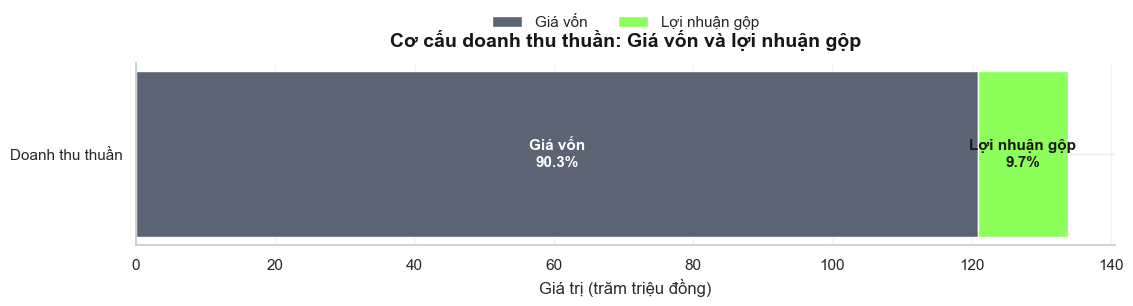

In [309]:
chart_2_components = pd.DataFrame(
    {
        'Cấu phần': ['Giá vốn', 'Lợi nhuận gộp'],
        'Giá trị': [total_cogs, total_gross_profit],
        'Tỷ trọng': [cogs_share_of_net_revenue, gross_profit_share_of_net_revenue],
        'Màu': [PALETTE['base_bar'], PALETTE['green']],
    }
)

fig, ax = plt.subplots(figsize=(11.5, 3.4))

left = 0.0
for _, row in chart_2_components.iterrows():
    ax.barh(
        ['Doanh thu thuần'],
        row['Giá trị'],
        left=left,
        color=row['Màu'],
        height=0.58,
        label=row['Cấu phần'],
    )
    ax.text(
        left + row['Giá trị'] / 2,
        0,
        f"{row['Cấu phần']}\n{row['Tỷ trọng']:.1%}",
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color=PALETTE['white'] if row['Cấu phần'] == 'Giá vốn' else PALETTE['black'],
    )
    left += row['Giá trị']

clean_axis(
    ax,
    xlabel='Giá trị (trăm triệu đồng)',
    ylabel='',
    title='Cơ cấu doanh thu thuần: Giá vốn và lợi nhuận gộp',
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
ax.grid(axis='x', alpha=0.25)
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(0.5, 1.22), loc='center')

plt.tight_layout()
plt.show()


- Từ **14.02 tỷ** gross sales, doanh nghiệp mất ngay **640.5 triệu** vào chiết khấu, còn lại **13.38 tỷ** doanh thu thuần. Nhưng trong **13.38 tỷ** đó, **12.09 tỷ** tiếp tục bị hấp thụ bởi giá vốn. Kết quả: mỗi **100 đồng** gross sales chỉ để lại **9.2 đồng** lợi nhuận gộp sau khi trừ **4.6 đồng** chiết khấu và **86.2 đồng** giá vốn.

- Khi giá vốn đã chiếm **86.2 đồng** trên mỗi 100 đồng gross sales, chỉ cần giá nhập hàng tăng nhẹ, mix sản phẩm dịch về nhóm biên thấp hơn, hoặc tỷ lệ chiết khấu tăng thêm vài điểm, **9.2 đồng** còn lại sẽ bị xóa gần hết. Đây là lý do tăng trưởng doanh thu thuần túy, không đi kèm kiểm soát giá vốn và discount sẽ không cải thiện được lợi nhuận thực tế.


### Chart 3 — Doanh thu thuần và biên lợi nhuận gộp theo năm

**Câu hỏi business:**  
Doanh nghiệp đã đạt scale tốt nhất ở giai đoạn nào, và chất lượng lợi nhuận của từng giai đoạn đó có bền vững hay không?


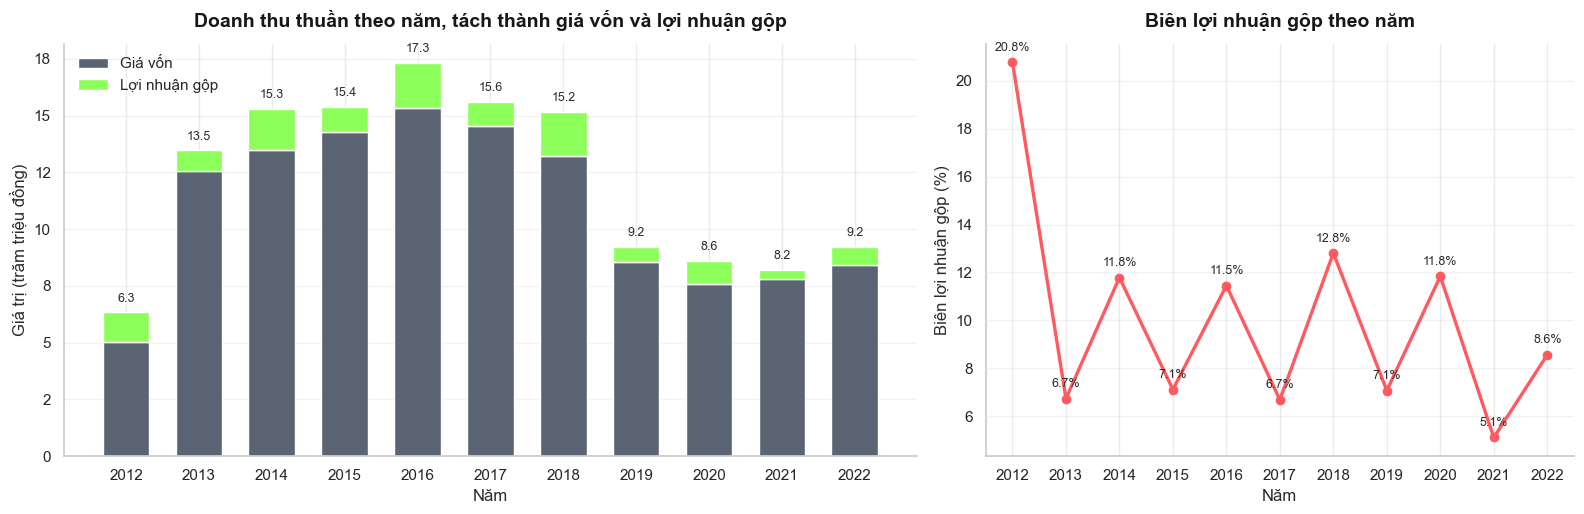

Năm có doanh thu thuần cao nhất: 2016 - 1,730,699,753
Năm có lợi nhuận gộp cao nhất: 2016 - 198,220,559
Năm có biên lợi nhuận gộp cao nhất: 2012 - 20.77%


In [310]:
year_positions = np.arange(len(yearly_business))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.3), gridspec_kw={'width_ratios': [1.45, 1]})

axes[0].bar(
    year_positions,
    yearly_business['cogs'],
    color=PALETTE['base_bar'],
    width=0.64,
    label='Giá vốn',
)
axes[0].bar(
    year_positions,
    yearly_business['gross_profit'],
    bottom=yearly_business['cogs'],
    color=PALETTE['green'],
    width=0.64,
    label='Lợi nhuận gộp',
)
clean_axis(
    axes[0],
    xlabel='Năm',
    ylabel='Giá trị (trăm triệu đồng)',
    title='Doanh thu thuần theo năm, tách thành giá vốn và lợi nhuận gộp',
)
axes[0].set_xticks(year_positions)
axes[0].set_xticklabels(yearly_business['year'].astype(int).astype(str))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(frameon=False, loc='upper left')

for idx, row in yearly_business.iterrows():
    axes[0].text(
        idx,
        row['net_revenue'] + yearly_business['net_revenue'].max() * 0.02,
        format_hundred_millions(row['net_revenue']),
        ha='center',
        va='bottom',
        fontsize=9,
        color=PALETTE['dark_gray'],
    )

axes[1].plot(
    year_positions,
    yearly_business['gross_margin'] * 100,
    color=PALETTE['risk_red'],
    linewidth=2.4,
    marker='o',
)
clean_axis(
    axes[1],
    xlabel='Năm',
    ylabel='Biên lợi nhuận gộp (%)',
    title='Biên lợi nhuận gộp theo năm',
)
axes[1].set_xticks(year_positions)
axes[1].set_xticklabels(yearly_business['year'].astype(int).astype(str))
axes[1].grid(axis='y', alpha=0.25)

for idx, row in yearly_business.iterrows():
    axes[1].text(
        idx,
        row['gross_margin'] * 100 + 0.35,
        f"{row['gross_margin'] * 100:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9,
        color=PALETTE['dark_gray'],
    )

plt.tight_layout()
plt.show()

best_year_revenue = yearly_business.loc[yearly_business['net_revenue'].idxmax()]
best_year_gp = yearly_business.loc[yearly_business['gross_profit'].idxmax()]
best_year_margin = yearly_business.loc[yearly_business['gross_margin'].idxmax()]

print('Năm có doanh thu thuần cao nhất:', int(best_year_revenue['year']), '-', format_currency(best_year_revenue['net_revenue']))
print('Năm có lợi nhuận gộp cao nhất:', int(best_year_gp['year']), '-', format_currency(best_year_gp['gross_profit']))
print('Năm có biên lợi nhuận gộp cao nhất:', int(best_year_margin['year']), '-', format_pct(best_year_margin['gross_margin']))

- **Về quy mô doanh thu:** Doanh thu tăng từ **633.4 triệu** năm 2012 lên đỉnh **1.73 tỷ** năm 2016 gấp gần **2.7 lần** trong bốn năm. Nhưng sau đó giảm liên tục về **821.1 triệu** năm 2021, mất đi hơn **52%** so với đỉnh. Năm 2022 phục hồi nhẹ lên **923.3 triệu** nhưng vẫn còn cách đỉnh cũ gần **810 triệu**.

- **Về chất lượng biên:** Năm 2016 khi doanh thu cao nhất gross margin chỉ đạt **11.45%** và lợi nhuận gộp tuyệt đối là **198.2 triệu**. Trong khi đó, năm 2012 với doanh thu chỉ bằng **1/3**, margin lại cao nhất toàn kỳ ở **20.77%**. Năm 2018 doanh thu thấp hơn 2016 rõ rệt nhưng margin lại tốt hơn ở **12.81%**. Chiều ngược lại, năm 2015 và 2017 doanh thu vẫn lớn nhưng margin chỉ quanh **7%** nghĩa là bán rất nhiều nhưng giữ lại rất ít. Đáy tệ nhất là năm 2021 khi cả doanh thu lẫn margin cùng thấp: **821.1 triệu** và chỉ **5.11%**.

- **Điều này nói lên điều gì?** Trong hơn 10 năm, chưa có năm nào doanh nghiệp vừa đạt đỉnh doanh thu vừa giữ được biên tốt cùng lúc. Tăng trưởng giai đoạn 2012–2016 nhiều khả năng được mua bằng việc hạ giá hoặc đẩy khuyến mãi, vì doanh thu tăng gần **3 lần** nhưng margin lại giảm từ **20.77%** xuống còn **11.45%**.


### Chart 4 — Giá trị hoàn tiền theo tháng trả hàng

**Câu hỏi business:**  
Ở những tháng nào doanh nghiệp chịu áp lực hoàn tiền thực tế cao nhất sau bán hàng, và pattern đó gợi ý vấn đề vận hành nào cần kiểm tra thêm?



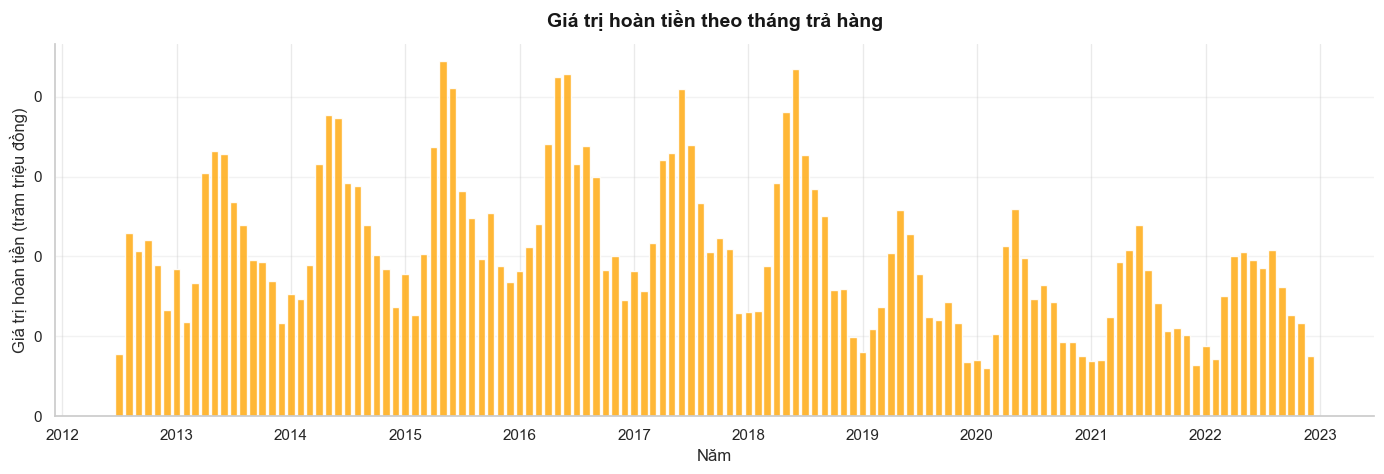

Tổng giá trị hoàn tiền: 510,598,507
Tháng có hoàn tiền cao nhất: 2015-05 - 8,884,003


,Tháng trả hàng,Giá trị hoàn tiền,Số lượng hoàn
34,2015-05,"8,884,003","1,752"
71,2018-06,"8,685,478","1,630"
47,2016-06,"8,577,972","1,750"
46,2016-05,"8,495,853","1,768"
35,2015-06,"8,224,575","1,640"


In [311]:
monthly_refunds = (
    returns_eda.groupby('return_month', as_index=False)
    .agg(
        refund_amount=('refund_amount', 'sum'),
        return_quantity=('return_quantity', 'sum'),
    )
    .sort_values('return_month')
)

top_refund_month = monthly_refunds.loc[monthly_refunds['refund_amount'].idxmax()]
top_refund_months = monthly_refunds.nlargest(5, 'refund_amount').copy()

fig, ax = plt.subplots(figsize=(14, 4.9))
ax.bar(
    monthly_refunds['return_month'],
    monthly_refunds['refund_amount'],
    color=PALETTE['warning'],
    width=24,
    alpha=0.9,
)
clean_axis(
    ax,
    xlabel='Năm',
    ylabel='Giá trị hoàn tiền (trăm triệu đồng)',
    title='Giá trị hoàn tiền theo tháng trả hàng',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('Tổng giá trị hoàn tiền:', format_currency(total_refund_amount))
print('Tháng có hoàn tiền cao nhất:', format_period(top_refund_month['return_month']), '-', format_currency(top_refund_month['refund_amount']))
display(
    top_refund_months.rename(
        columns={
            'return_month': 'Tháng trả hàng',
            'refund_amount': 'Giá trị hoàn tiền',
            'return_quantity': 'Số lượng hoàn',
        }
    ).assign(
        **{
            'Tháng trả hàng': lambda df: df['Tháng trả hàng'].map(format_period),
            'Giá trị hoàn tiền': lambda df: df['Giá trị hoàn tiền'].map(format_currency),
            'Số lượng hoàn': lambda df: df['Số lượng hoàn'].map(format_number),
        }
    )
)

- Tổng **510.6 triệu** hoàn tiền không phân bổ đều qua các tháng. Năm tháng có hoàn tiền cao nhất **2015-05** (**8.88 triệu**), **2018-06** (**8.69 triệu**), **2016-06** (**8.58 triệu**), **2016-05** (**8.50 triệu**) và **2015-06** (**8.22 triệu**) đều rơi vào **tháng 5 hoặc tháng 6**, và lặp lại ở nhiều năm khác nhau.

- Pattern này không ngẫu nhiên. Tháng 5–6 trùng với giai đoạn Spring Sale khi doanh nghiệp đẩy mạnh khuyến mãi và doanh thu đạt đỉnh mùa vụ. Khi khách hàng mua nhiều hơn nhu cầu thực vì giá tốt, một phần tất yếu sẽ quay lại trả hàng sau đó. Cứ mỗi đợt sale lớn, doanh nghiệp đang đổi lấy một đợt hoàn tiền tương ứng vài tuần sau và điều này lặp lại đủ đều để thành chu kỳ.


### Chart 5 — Cơ cấu giá trị thanh toán theo số kỳ trả góp

**Câu hỏi business:**  
Bao nhiêu giá trị thanh toán đang nằm trong các đơn nhiều kỳ, và mức phơi nhiễm này nói gì về **chất lượng doanh thu và áp lực thu tiền chậm theo proxy**?

> ⚠️ Đây là **collection-delay proxy**, không phải dòng tiền thu thực tế.



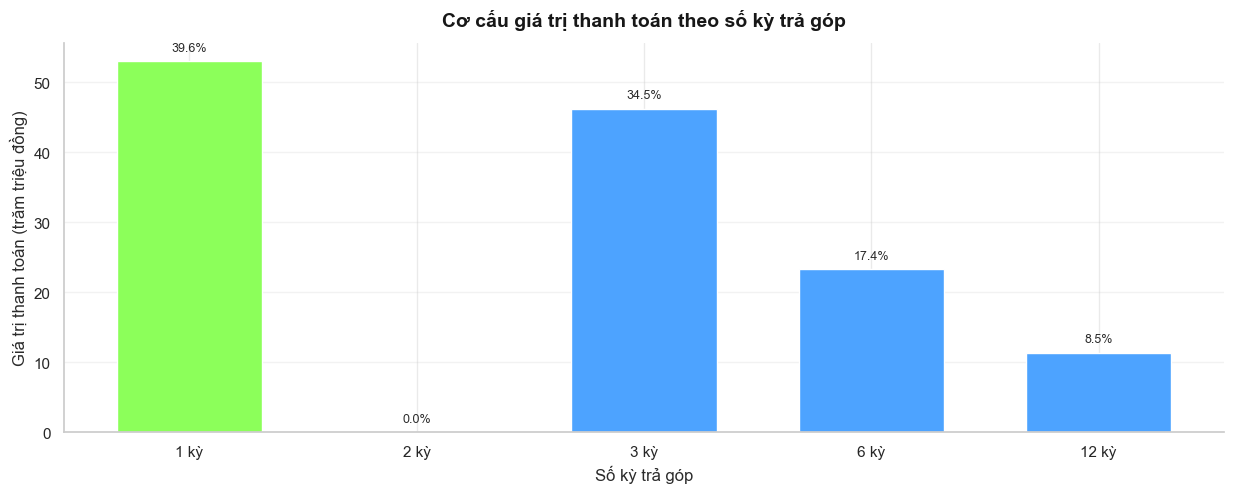

Tỷ trọng giá trị thanh toán trả góp nhiều kỳ: 60.38%
Tỷ lệ estimated deferred exposure (proxy): 45.27%


,Số kỳ trả góp,Số đơn hàng,Giá trị thanh toán,Tỷ trọng giá trị thanh toán,Ước tính phần thu kỳ đầu,Ước tính phần thu chậm,Tỷ lệ phần thu chậm
0,1 kỳ,"220,082","5,302,694,923",39.62%,"5,302,694,923",0,0.00%
1,2 kỳ,939,"664,679",0.00%,"332,339","332,339",50.00%
2,3 kỳ,"189,843","4,621,227,511",34.53%,"1,540,409,170","3,080,818,341",66.67%
3,6 kỳ,"95,157","2,325,581,563",17.38%,"387,596,927","1,937,984,636",83.33%
4,12 kỳ,"46,837","1,133,945,997",8.47%,"94,495,500","1,039,450,497",91.67%


In [312]:
payment_value_share_labels = [f"{value * 100:.1f}%" for value in installment_mix['payment_value_share']]
bar_colors = [PALETTE['green'] if inst == 1 else PALETTE['info_blue'] for inst in installment_mix['installments']]

fig, ax = plt.subplots(figsize=(12.5, 5.1))
ax.bar(
    installment_mix['installment_label'],
    installment_mix['payment_value'],
    color=bar_colors,
    width=0.64,
)
clean_axis(
    ax,
    xlabel='Số kỳ trả góp',
    ylabel='Giá trị thanh toán (trăm triệu đồng)',
    title='Cơ cấu giá trị thanh toán theo số kỳ trả góp',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
ax.grid(axis='y', alpha=0.25)

for idx, row in installment_mix.iterrows():
    ax.text(
        idx,
        row['payment_value'] + installment_mix['payment_value'].max() * 0.02,
        payment_value_share_labels[idx],
        ha='center',
        va='bottom',
        fontsize=9,
        color=PALETTE['dark_gray'],
    )

plt.tight_layout()
plt.show()

print('Tỷ trọng giá trị thanh toán trả góp nhiều kỳ:', format_pct(multi_installment_payment_share))
print('Tỷ lệ estimated deferred exposure (proxy):', format_pct(overall_deferred_exposure_ratio))
display(
    installment_mix.rename(
        columns={
            'installment_label': 'Số kỳ trả góp',
            'payment_value': 'Giá trị thanh toán',
            'payment_value_share': 'Tỷ trọng giá trị thanh toán',
            'estimated_first_period_collection': 'Ước tính phần thu kỳ đầu',
            'estimated_deferred_exposure': 'Ước tính phần thu chậm',
            'deferred_exposure_ratio': 'Tỷ lệ phần thu chậm',
            'order_count': 'Số đơn hàng',
        }
    )[[
        'Số kỳ trả góp',
        'Số đơn hàng',
        'Giá trị thanh toán',
        'Tỷ trọng giá trị thanh toán',
        'Ước tính phần thu kỳ đầu',
        'Ước tính phần thu chậm',
        'Tỷ lệ phần thu chậm',
    ]].assign(
        **{
            'Số đơn hàng': lambda df: df['Số đơn hàng'].map(format_number),
            'Giá trị thanh toán': lambda df: df['Giá trị thanh toán'].map(format_currency),
            'Tỷ trọng giá trị thanh toán': lambda df: df['Tỷ trọng giá trị thanh toán'].map(format_pct),
            'Ước tính phần thu kỳ đầu': lambda df: df['Ước tính phần thu kỳ đầu'].map(format_currency),
            'Ước tính phần thu chậm': lambda df: df['Ước tính phần thu chậm'].map(format_currency),
            'Tỷ lệ phần thu chậm': lambda df: df['Tỷ lệ phần thu chậm'].map(format_pct),
        }
    )
)

- Chỉ **39.62%** giá trị thanh toán đến từ đơn trả một kỳ. **60.38%** còn lại nằm ở đơn nhiều kỳ, trong đó plan **3 kỳ** chiếm **34.53%** và **6 kỳ** chiếm **17.38%** cộng lại đã là **52%** tổng payment value, tức đây là cấu trúc vận hành phổ biến nhất chứ không phải ngoại lệ. Plan **12 kỳ** chiếm thêm **8.47%**, và với kỳ hạn này, phần tiền chưa thu về theo proxy lên tới **91.67%** giá trị đơn hàng ngay sau lần thanh toán đầu tiên.

- Tính chung toàn bộ đơn nhiều kỳ, phần thanh toán bị hoãn thu theo proxy ước tính khoảng **45.27%** tổng payment value tức gần một nửa doanh thu đã ghi nhận vẫn đang nằm trên sổ sách chứ chưa thực sự về tài khoản. Trong bối cảnh biên gộp chỉ **9.69%**, nếu một phần trong số đó phát sinh hoàn trả hoặc không thu được đủ, lợi nhuận thực tế sẽ thấp hơn con số kế toán đáng kể.


**Điểm cần theo dõi thêm:**  
- Plan **3 kỳ + 6 kỳ** đã chiếm gần **52%** payment value, nên đây là pattern vận hành chủ đạo chứ không phải nhóm rìa.  
- Với plan **12 kỳ**, tỷ lệ phần thu chậm theo proxy lên tới **91.67%**, vì vậy chỉ một tỷ trọng nhỏ về doanh thu cũng có thể kéo áp lực quản trị collection lên đáng kể.  
- Ban điều hành nên xem thêm cohort trả góp theo kỳ hạn để biết liệu doanh nghiệp đang tối ưu conversion hay đang tích lũy rủi ro thu tiền chậm ở những nhóm khách hàng biên mỏng.


### Chart 6 — Mùa vụ doanh thu và biên lợi nhuận gộp

**Câu hỏi business:**  
Tháng nào là mùa mạnh thật sự của doanh nghiệp khi đọc đồng thời **doanh thu** và **gross margin**, thay vì chỉ nhìn volume bán ra?


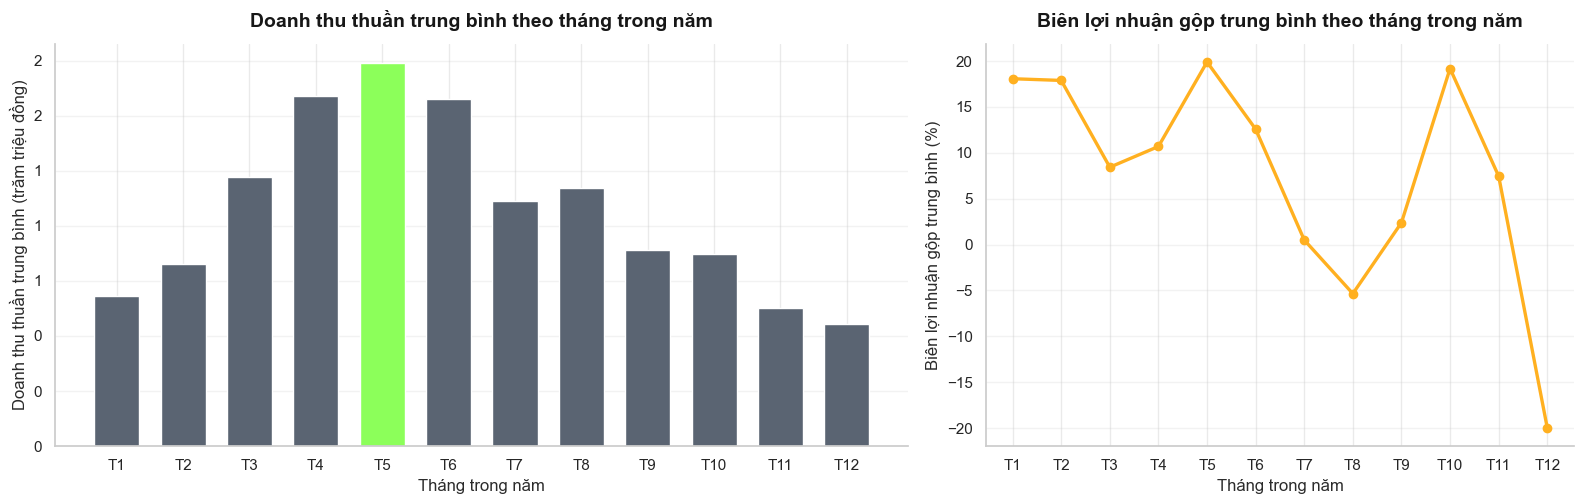

Tháng có doanh thu thuần trung bình cao nhất: T5 - 173,963,141


In [313]:
best_calendar_month = calendar_month_profile.loc[calendar_month_profile['avg_net_revenue'].idxmax(), 'month']
revenue_colors = [
    PALETTE['green'] if month == best_calendar_month else PALETTE['base_bar']
    for month in calendar_month_profile['month']
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={'width_ratios': [1.45, 1]})

axes[0].bar(
    calendar_month_profile['month_label'],
    calendar_month_profile['avg_net_revenue'],
    color=revenue_colors,
    width=0.68,
)
clean_axis(
    axes[0],
    xlabel='Tháng trong năm',
    ylabel='Doanh thu thuần trung bình (trăm triệu đồng)',
    title='Doanh thu thuần trung bình theo tháng trong năm',
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[0].grid(axis='y', alpha=0.25)

axes[1].plot(
    calendar_month_profile['month_label'],
    calendar_month_profile['avg_gross_margin'] * 100,
    color=PALETTE['warning'],
    linewidth=2.4,
    marker='o',
)
clean_axis(
    axes[1],
    xlabel='Tháng trong năm',
    ylabel='Biên lợi nhuận gộp trung bình (%)',
    title='Biên lợi nhuận gộp trung bình theo tháng trong năm',
)
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

best_month_row = calendar_month_profile.loc[calendar_month_profile['avg_net_revenue'].idxmax()]
print('Tháng có doanh thu thuần trung bình cao nhất:', best_month_row['month_label'], '-', format_currency(best_month_row['avg_net_revenue']))

- **Về doanh thu:** Tháng 5 dẫn đầu với trung bình **174 triệu/tháng**, tiếp theo là tháng 4 (**158.8 triệu**) và tháng 6 (**157.7 triệu**). Cuối năm lại là đáy: tháng 11 chỉ **62.7 triệu** và tháng 12 là **55.4 triệu** chưa bằng **1/3** so với đỉnh tháng 5, và ngược hoàn toàn với kỳ vọng bùng nổ cuối năm thường thấy ở ngành bán lẻ.

- **Về biên lợi nhuận:** Tháng 5 không chỉ dẫn đầu doanh thu mà còn có margin cao nhất ở **19.9%** gấp hơn **2 lần** mức trung bình toàn kỳ **9.69%**. Tháng 10 cũng giữ margin tốt ở **19.2%** nhưng doanh thu chỉ **87.2 triệu**, bằng một nửa tháng 5. Ở chiều ngược lại, tháng 8 có margin trung bình **âm 5.35%** và tháng 12 **âm gần 20%** nghĩa là trung bình các năm, doanh nghiệp đang bán lỗ ở hai tháng này. Tháng 7 và 9 cũng chỉ loanh quanh điểm hòa vốn.

- **Bài học:** Cụm tháng 4–6 đặc biệt tháng 5 là thời điểm duy nhất trong năm doanh nghiệp vừa bán được nhiều vừa giữ được biên tốt. Ngược lại, từ tháng 7 đến tháng 12, doanh thu thấp hơn mà margin lại xấu hơn, thậm chí âm ở hai tháng cuối năm, gợi ý đây là giai đoạn doanh nghiệp đang tiêu tốn nguồn lực nhiều hơn là tạo ra giá trị.


### Tổng kết Lớp 1 — Bức tranh tài chính sơ bộ của doanh nghiệp

> **Đây là một doanh nghiệp có quy mô đáng kể, từng tăng trưởng gần 3 lần từ 2012 đến 2016, nhưng đang vận hành trên biên gộp chỉ 9.69% trong khi 510.6 triệu hoàn tiền và 60% giá trị thanh toán chưa thu về đang tích lũy ở phía sau.**

Điểm mấu chốt là những vấn đề này có thể không ảnh hưởng đều lên toàn bộ tệp khách hàng. Rất có thể một nhóm nhỏ đang tạo ra phần lớn trong **1.30 tỷ** lợi nhuận gộp thực sự, trong khi một nhóm khác dù đóng góp vào **13.38 tỷ** doanh thu, lại đang kéo biên xuống và gây phần lớn chi phí sau bán hàng. Xác định được hai nhóm đó là bài toán trung tâm của Lớp 2.

#### Vòng đời đơn hàng: Doanh thu hoàn tất, pipeline mở và giá trị bị huỷ

- Phần tài chính chính đã khóa vào completed baseline để đọc doanh thu và lợi nhuận đã hoàn tất. Tuy nhiên, để chuẩn bị cho Customer Diagnosis, cần phân tích thêm các trạng thái ngoài completed baseline.

- Các đơn `created`, `paid`, `shipped` không được xem là revenue chính, mà là open pipeline — nhu cầu đã phát sinh nhưng chưa hoàn tất. Các đơn `cancelled` không được xem là revenue, mà là lost demand, giá trị đơn hàng bị mất trước khi chuyển hóa thành doanh thu hoàn tất.

- Phần này nhằm trả lời: giá trị đang treo và giá trị bị huỷ lớn đến đâu, đang kẹt ở bước nào, và tập trung ở kênh/nhóm nào. Đây là nền để phần Customer phía sau phân biệt khách hàng sinh lời thật với khách hàng chỉ tạo demand nhưng không convert.

In [314]:
open_pipeline_status = ['created', 'paid', 'shipped']
completed_status = ['delivered', 'returned']

payment_order_level_all = (
    payments.groupby('order_id', as_index=False)
    .agg(
        payment_value=('payment_value', 'sum'),
        installments=('installments', 'max'),
        payment_method=('payment_method', 'first'),
    )
)
payment_order_level_all['installments'] = (
    payment_order_level_all['installments'].fillna(1).clip(lower=1).astype(int)
)

order_value_fact = (
    all_order_line_fact.groupby('order_id', as_index=False)
    .agg(
        gross_order_value=('gross_line_sales', 'sum'),
        discount_amount=('discount_amount', 'sum'),
        net_order_value=('line_revenue', 'sum'),
    )
)

geo_lookup = geography[['zip', 'region', 'city']].drop_duplicates('zip')

order_lifecycle_fact = (
    orders[['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']]
    .merge(order_value_fact, on='order_id', how='left')
    .merge(payment_order_level_all, on='order_id', how='left', suffixes=('_order', '_payment'))
    .merge(geo_lookup, on='zip', how='left')
)

for col in ['gross_order_value', 'discount_amount', 'net_order_value', 'payment_value']:
    order_lifecycle_fact[col] = order_lifecycle_fact[col].fillna(0)

order_lifecycle_fact['installments'] = (
    order_lifecycle_fact['installments'].fillna(1).clip(lower=1).astype(int)
)
order_lifecycle_fact['payment_method_resolved'] = (
    order_lifecycle_fact['payment_method_payment']
    .fillna(order_lifecycle_fact['payment_method_order'])
    .fillna('unknown')
)
order_lifecycle_fact['region'] = order_lifecycle_fact['region'].fillna('Unknown')
order_lifecycle_fact['order_source'] = order_lifecycle_fact['order_source'].fillna('Unknown')
order_lifecycle_fact['is_multi_installment'] = order_lifecycle_fact['installments'].gt(1)

order_lifecycle_fact['completed_order_flag'] = order_lifecycle_fact['order_status'].isin(completed_status).astype(int)
order_lifecycle_fact['open_pipeline_order_flag'] = order_lifecycle_fact['order_status'].isin(open_pipeline_status).astype(int)
order_lifecycle_fact['cancelled_order_flag'] = order_lifecycle_fact['order_status'].eq('cancelled').astype(int)

order_lifecycle_fact['completed_net_value'] = np.where(
    order_lifecycle_fact['completed_order_flag'].eq(1),
    order_lifecycle_fact['net_order_value'],
    0,
)
order_lifecycle_fact['open_pipeline_net_value'] = np.where(
    order_lifecycle_fact['open_pipeline_order_flag'].eq(1),
    order_lifecycle_fact['net_order_value'],
    0,
)
order_lifecycle_fact['cancelled_net_value'] = np.where(
    order_lifecycle_fact['cancelled_order_flag'].eq(1),
    order_lifecycle_fact['net_order_value'],
    0,
)

print('Tổng số đơn trong order_lifecycle_fact:', format_number(order_lifecycle_fact['order_id'].nunique()))
display(
    order_lifecycle_fact[
        [
            'order_id', 'customer_id', 'order_status', 'order_source', 'region',
            'gross_order_value', 'discount_amount', 'net_order_value',
            'payment_method_resolved', 'installments'
        ]
    ].head()
)


Tổng số đơn trong order_lifecycle_fact: 646,945


,order_id,customer_id,order_status,order_source,region,gross_order_value,discount_amount,net_order_value,payment_method_resolved,installments
0,1,58578,delivered,paid_search,East,7967.54,0.0,7967.54,credit_card,3
1,2,58621,returned,paid_search,East,71163.75,0.0,71163.75,cod,1
2,3,58811,delivered,direct,East,33660.99,0.0,33660.99,credit_card,3
3,4,59453,delivered,referral,East,53196.25,0.0,53196.25,credit_card,3
4,6,57821,delivered,email_campaign,East,1597.84,0.0,1597.84,paypal,1


### Open Pipeline & Cancellation Diagnosis

**Câu hỏi business:**  
Open pipeline hiện lớn đến đâu, cancelled value đang làm mất bao nhiêu unrealized demand, và leakage này đang tập trung ở bước nào của funnel trước khi đi sang Customer Diagnosis?


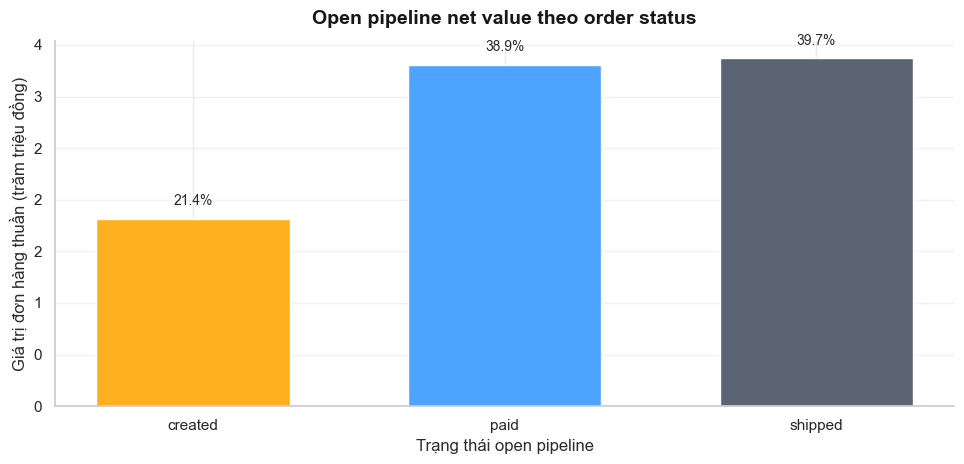

,Open pipeline status,Số đơn open pipeline,Giá trị đơn hàng thuần open pipeline,Tỷ trọng giá trị open pipeline,Giá trị trung bình mỗi đơn open pipeline
0,created,"7,275","181,835,019",21.40%,"24,995"
1,paid,"13,577","330,627,096",38.91%,"24,352"
2,shipped,"13,773","337,278,840",39.69%,"24,488"


,Chỉ số,Giá trị
0,Completed net value,"13,384,114,673"
1,Open pipeline net value,"849,740,955"
2,Cancelled net value (lost order value),"1,447,013,637"
3,Cancelled value / completed value,10.81%


In [315]:
open_pipeline_summary = (
    order_lifecycle_fact.loc[order_lifecycle_fact['order_status'].isin(open_pipeline_status)]
    .groupby('order_status', as_index=False)
    .agg(
        open_pipeline_order_count=('order_id', 'nunique'),
        open_pipeline_net_value=('net_order_value', 'sum'),
    )
)
open_pipeline_total_value = open_pipeline_summary['open_pipeline_net_value'].sum()
open_pipeline_summary['open_pipeline_value_share'] = (
    open_pipeline_summary['open_pipeline_net_value'] / open_pipeline_total_value
)
open_pipeline_summary['avg_open_pipeline_value_per_order'] = (
    open_pipeline_summary['open_pipeline_net_value']
    / open_pipeline_summary['open_pipeline_order_count'].replace(0, np.nan)
)

fig, ax = plt.subplots(figsize=(9.8, 4.8))
ax.bar(
    open_pipeline_summary['order_status'],
    open_pipeline_summary['open_pipeline_net_value'],
    color=[PALETTE['warning'], PALETTE['info_blue'], PALETTE['base_bar']],
    width=0.62,
)
clean_axis(
    ax,
    xlabel='Trạng thái open pipeline',
    ylabel='Giá trị đơn hàng thuần (trăm triệu đồng)',
    title='Open pipeline net value theo order status',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
ax.grid(axis='y', alpha=0.25)
for idx, row in open_pipeline_summary.iterrows():
    ax.text(
        idx,
        row['open_pipeline_net_value'] + open_pipeline_summary['open_pipeline_net_value'].max() * 0.03,
        f"{row['open_pipeline_value_share']:.1%}",
        ha='center',
        va='bottom',
        fontsize=10,
        color=PALETTE['dark_gray'],
    )
plt.tight_layout()
plt.show()

display(
    open_pipeline_summary.rename(
        columns={
            'order_status': 'Open pipeline status',
            'open_pipeline_order_count': 'Số đơn open pipeline',
            'open_pipeline_net_value': 'Giá trị đơn hàng thuần open pipeline',
            'open_pipeline_value_share': 'Tỷ trọng giá trị open pipeline',
            'avg_open_pipeline_value_per_order': 'Giá trị trung bình mỗi đơn open pipeline',
        }
    ).assign(
        **{
            'Số đơn open pipeline': lambda df: df['Số đơn open pipeline'].map(format_number),
            'Giá trị đơn hàng thuần open pipeline': lambda df: df['Giá trị đơn hàng thuần open pipeline'].map(format_currency),
            'Tỷ trọng giá trị open pipeline': lambda df: df['Tỷ trọng giá trị open pipeline'].map(format_pct),
            'Giá trị trung bình mỗi đơn open pipeline': lambda df: df['Giá trị trung bình mỗi đơn open pipeline'].map(format_currency),
        }
    )
)

completed_net_value = order_lifecycle_fact['completed_net_value'].sum()
cancelled_net_value = order_lifecycle_fact['cancelled_net_value'].sum()
cancelled_value_to_completed_ratio = cancelled_net_value / completed_net_value

cancellation_value_kpi = pd.DataFrame(
    {
        'Chỉ số': [
            'Completed net value',
            'Open pipeline net value',
            'Cancelled net value (lost order value)',
            'Cancelled value / completed value',
        ],
        'Giá trị': [
            completed_net_value,
            open_pipeline_total_value,
            cancelled_net_value,
            cancelled_value_to_completed_ratio,
        ],
    }
)

display(
    cancellation_value_kpi.assign(
        Giá_trị_hiển_thị=lambda df: [
            format_currency(value) if idx < 3 else format_pct(value)
            for idx, value in enumerate(df['Giá trị'])
        ]
    )[['Chỉ số', 'Giá_trị_hiển_thị']].rename(columns={'Giá_trị_hiển_thị': 'Giá trị'})
)


**Điểm đọc chính:**  
- Open pipeline hiện giữ khoảng **849.7 triệu** giá trị đơn hàng thuần chưa hoàn tất. `shipped` chiếm **337.3 triệu** (**39.7%**), `paid` chiếm **330.6 triệu** (**38.9%**), còn `created` là **181.8 triệu** (**21.4%**).  
- Giá trị trung bình mỗi đơn open pipeline khá đồng đều, quanh **24.4–25.0 nghìn** mỗi đơn. Điều này cho thấy leakage không nằm ở một nhóm đơn quá lớn, mà có tính hệ thống theo volume.  
- `Cancelled` đang giữ **1.447 tỷ** lost order value, tương đương **10.81%** completed net value và lớn hơn toàn bộ open pipeline khoảng **1.7 lần**.

**Insight tài chính / vận hành:**  
`Created` nên được đọc như dấu hiệu của **checkout/payment friction**. `Paid` phản ánh **fulfillment bottleneck** vì nhu cầu đã xác nhận nhưng chưa đi tiếp. `Shipped` phản ánh **logistics/delivery risk** vì doanh nghiệp đã tiêu tốn nguồn lực vận hành nhưng giá trị vẫn chưa hoàn tất. Quan trọng hơn, cancelled value còn lớn hơn cả open pipeline, nghĩa là trước khi đánh giá chất lượng khách hàng, doanh nghiệp cần hiểu rõ phần demand nào đang rơi khỏi hệ thống thay vì chuyển hóa thành completed value thật.

**Hàm ý quản trị:**  
Cancel cần được phân tích trước Customer Diagnosis vì nếu không tách lớp này ra, doanh nghiệp rất dễ đánh giá sai một tệp khách hàng hoặc một acquisition channel là tốt chỉ vì tạo nhiều demand trên giấy.


### Cancel by Order Source

**Câu hỏi business:**  
Kênh nào đang tạo demand có chất lượng vòng đời thấp hơn, tức tạo đơn nhưng để lại tỷ trọng lost order value cao hơn?


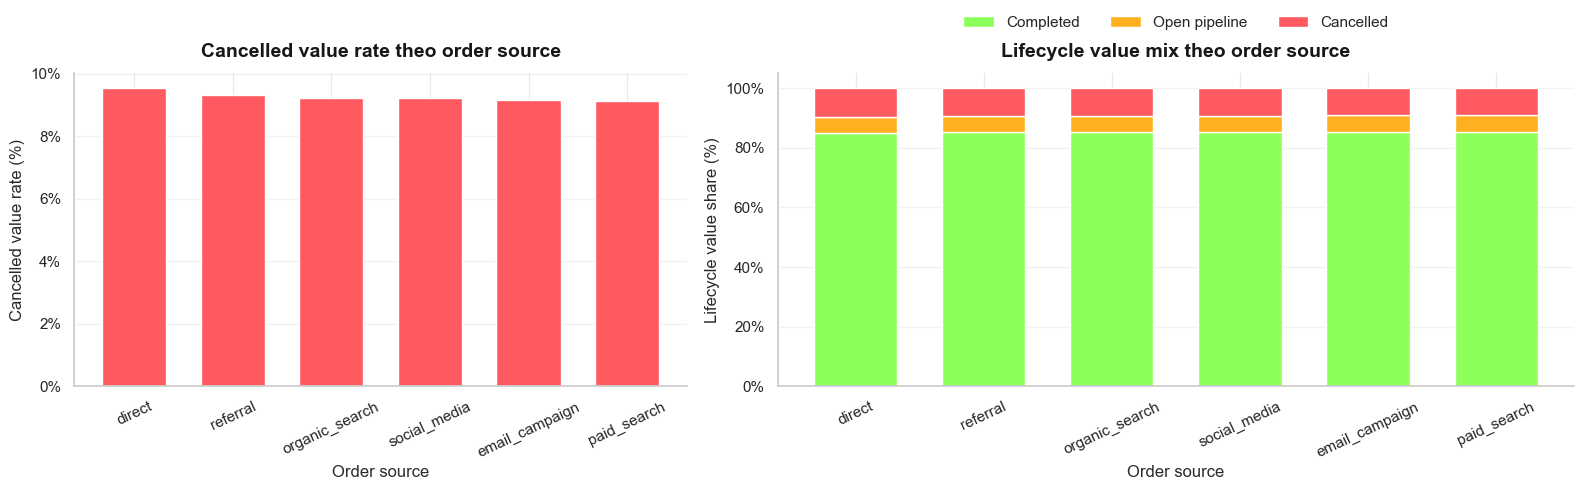

,order_source,total_order_count,cancelled_order_count,total_net_value,completed_net_value,open_pipeline_net_value,cancelled_net_value,completed_value_rate,open_pipeline_value_rate,cancelled_value_rate,cancelled_order_rate
0,direct,"51,951","4,822","1,264,049,900","1,074,137,822","69,346,960","120,565,119",84.98%,5.49%,9.54%,9.28%
1,referral,"64,565","6,028","1,565,897,314","1,336,608,145","83,316,975","145,972,194",85.36%,5.32%,9.32%,9.34%
2,organic_search,"181,495","16,743","4,385,324,882","3,743,292,935","237,109,432","404,922,515",85.36%,5.41%,9.23%,9.23%
3,social_media,"129,710","11,844","3,141,153,470","2,681,818,742","169,999,021","289,335,707",85.38%,5.41%,9.21%,9.13%
4,email_campaign,"77,572","7,132","1,882,479,281","1,608,162,202","101,882,205","172,434,875",85.43%,5.41%,9.16%,9.19%
5,paid_search,"141,652","12,893","3,441,964,418","2,940,094,828","188,086,363","313,783,228",85.42%,5.46%,9.12%,9.10%


In [316]:
source_lifecycle_summary = (
    order_lifecycle_fact.groupby('order_source', as_index=False)
    .agg(
        total_order_count=('order_id', 'nunique'),
        cancelled_order_count=('cancelled_order_flag', 'sum'),
        total_net_value=('net_order_value', 'sum'),
        completed_net_value=('completed_net_value', 'sum'),
        open_pipeline_net_value=('open_pipeline_net_value', 'sum'),
        cancelled_net_value=('cancelled_net_value', 'sum'),
    )
)
source_lifecycle_summary['completed_value_rate'] = (
    source_lifecycle_summary['completed_net_value'] / source_lifecycle_summary['total_net_value'].replace(0, np.nan)
)
source_lifecycle_summary['open_pipeline_value_rate'] = (
    source_lifecycle_summary['open_pipeline_net_value'] / source_lifecycle_summary['total_net_value'].replace(0, np.nan)
)
source_lifecycle_summary['cancelled_value_rate'] = (
    source_lifecycle_summary['cancelled_net_value'] / source_lifecycle_summary['total_net_value'].replace(0, np.nan)
)
source_lifecycle_summary['cancelled_order_rate'] = (
    source_lifecycle_summary['cancelled_order_count'] / source_lifecycle_summary['total_order_count'].replace(0, np.nan)
)
source_lifecycle_summary = source_lifecycle_summary.sort_values('cancelled_value_rate', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={'width_ratios': [1, 1.3]})

axes[0].bar(
    source_lifecycle_summary['order_source'],
    source_lifecycle_summary['cancelled_value_rate'] * 100,
    color=PALETTE['risk_red'],
    width=0.65,
)
clean_axis(
    axes[0],
    xlabel='Order source',
    ylabel='Cancelled value rate (%)',
    title='Cancelled value rate theo order source',
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_phan_tram))
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.25)

bottom = np.zeros(len(source_lifecycle_summary))
for col, color, label in [
    ('completed_value_rate', PALETTE['green'], 'Completed'),
    ('open_pipeline_value_rate', PALETTE['warning'], 'Open pipeline'),
    ('cancelled_value_rate', PALETTE['risk_red'], 'Cancelled'),
]:
    axes[1].bar(
        source_lifecycle_summary['order_source'],
        source_lifecycle_summary[col] * 100,
        bottom=bottom * 100,
        color=color,
        width=0.65,
        label=label,
    )
    bottom += source_lifecycle_summary[col].fillna(0)
clean_axis(
    axes[1],
    xlabel='Order source',
    ylabel='Lifecycle value share (%)',
    title='Lifecycle value mix theo order source',
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(axis_phan_tram))
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(frameon=False, ncol=3, bbox_to_anchor=(0.5, 1.16), loc='center')

plt.tight_layout()
plt.show()

display(
    source_lifecycle_summary.assign(
        **{
            'total_order_count': lambda df: df['total_order_count'].map(format_number),
            'cancelled_order_count': lambda df: df['cancelled_order_count'].map(format_number),
            'total_net_value': lambda df: df['total_net_value'].map(format_currency),
            'completed_net_value': lambda df: df['completed_net_value'].map(format_currency),
            'open_pipeline_net_value': lambda df: df['open_pipeline_net_value'].map(format_currency),
            'cancelled_net_value': lambda df: df['cancelled_net_value'].map(format_currency),
            'completed_value_rate': lambda df: df['completed_value_rate'].map(format_pct),
            'open_pipeline_value_rate': lambda df: df['open_pipeline_value_rate'].map(format_pct),
            'cancelled_value_rate': lambda df: df['cancelled_value_rate'].map(format_pct),
            'cancelled_order_rate': lambda df: df['cancelled_order_rate'].map(format_pct),
        }
    )
)


**Điểm đọc chính:**  
- Chênh lệch cancelled value rate giữa các source không quá rộng, chỉ quanh **9.1%–9.5%**. `direct` cao nhất khoảng **9.54%**, trong khi `paid_search` thấp hơn nhẹ ở khoảng **9.12%**.  
- `Open pipeline value rate` cũng khá đồng đều, quanh **5.3%–5.5%** ở hầu hết kênh.  
- Tuy nhiên, scale của từng source rất khác nhau. `organic_search`, `paid_search` và `social_media` tạo base value lớn nhất, nên vẫn đóng góp phần lớn absolute leakage.

**Insight tài chính / vận hành:**  
Chart này nhấn mạnh rằng **kênh tạo nhiều đơn chưa chắc là kênh tốt nếu quality of conversion không cao**. Trong dữ liệu hiện tại, không có một source nào gãy hẳn về lifecycle quality, nhưng các nguồn lớn vẫn tạo ra lost order value lớn về mặt tuyệt đối chỉ vì volume cao. Vì vậy, hiệu quả kênh cần được đọc bằng completed value rate chứ không chỉ bằng tổng demand đầu vào.


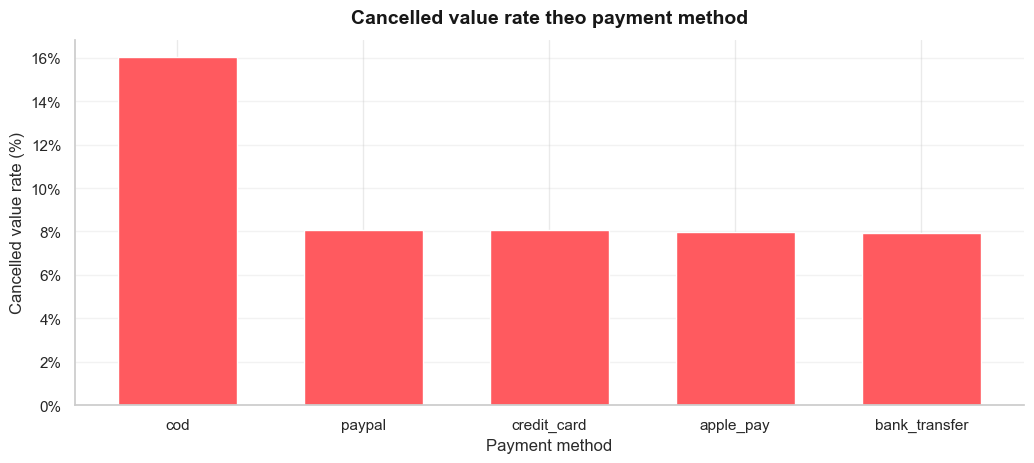

,payment_method_resolved,total_order_count,cancelled_order_count,total_net_value,completed_net_value,cancelled_net_value,avg_installments,multi_installment_order_rate,avg_net_order_value,cancelled_value_rate,cancelled_order_rate
0,cod,"96,681","15,468","2,346,947,593","1,841,100,270","376,297,113",1.00,0.00%,"24,275",16.03%,16.00%
1,paypal,"97,018","7,817","2,363,680,138","2,047,258,581","190,228,852",3.88,69.70%,"24,363",8.05%,8.06%
2,credit_card,"356,352","28,452","8,630,069,413","7,467,651,337","694,304,086",3.88,69.85%,"24,218",8.05%,7.98%
3,apple_pay,"64,763","5,190","1,564,269,610","1,355,680,532","124,816,586",3.88,69.96%,"24,154",7.98%,8.01%
4,bank_transfer,"32,131","2,535","775,902,511","672,423,952","61,367,000",3.85,69.21%,"24,148",7.91%,7.89%


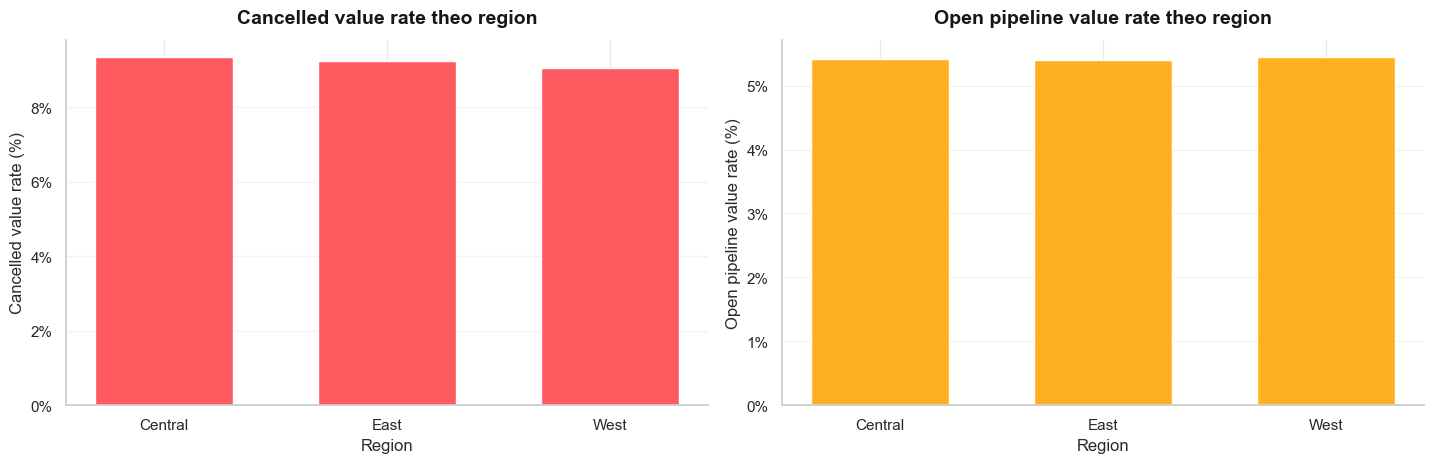

Số khách hàng trong customer_lifecycle_summary: 90,246


,customer_id,total_order_count,completed_order_count,open_pipeline_order_count,cancelled_order_count,total_net_order_value,completed_net_value,open_pipeline_net_value,cancelled_net_value,completed_order_rate,open_pipeline_order_rate,cancelled_order_rate,completed_value_rate,open_pipeline_value_rate,cancelled_value_rate
0,1,6,5,1,0,142803.47,100261.22,42542.25,0.00,0.833333,0.166667,0.000000,0.702092,0.297908,0.000000
1,2,4,2,0,2,204693.89,126255.29,0.00,78438.60,0.500000,0.000000,0.500000,0.616800,0.000000,0.383200
2,3,3,2,0,1,52093.47,12001.55,0.00,40091.92,0.666667,0.000000,0.333333,0.230385,0.000000,0.769615
3,4,1,1,0,0,10939.06,10939.06,0.00,0.00,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
4,5,5,5,0,0,64179.86,64179.86,0.00,0.00,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000


,count,mean,std,min,25%,50%,75%,max
total_order_count,90246.0,7.168683,8.629654,1.00,2.000000,4.000,9.000000,107.00
completed_order_count,90246.0,6.126122,7.440299,0.00,1.000000,3.000,8.000000,97.00
open_pipeline_order_count,90246.0,0.383674,0.756718,0.00,0.000000,0.000,1.000000,9.00
cancelled_order_count,90246.0,0.658888,1.102509,0.00,0.000000,0.000,1.000000,16.00
total_net_order_value,90246.0,173756.945077,218540.979950,438.94,31148.520000,89906.400,233582.372500,3503583.41
completed_net_value,90246.0,148307.012752,189141.393276,0.00,24775.982500,76822.115,199986.217500,3244730.02
open_pipeline_net_value,90246.0,9415.829568,23323.746142,0.00,0.000000,0.000,4024.440000,391295.84
cancelled_net_value,90246.0,16034.102757,32561.257132,0.00,0.000000,0.000,17867.720000,499582.85
completed_order_rate,90246.0,0.854292,0.226390,0.00,0.800000,1.000,1.000000,1.00
open_pipeline_order_rate,90246.0,0.054004,0.146013,0.00,0.000000,0.000,0.043478,1.00


In [317]:
payment_lifecycle_summary = (
    order_lifecycle_fact.groupby('payment_method_resolved', as_index=False)
    .agg(
        total_order_count=('order_id', 'nunique'),
        cancelled_order_count=('cancelled_order_flag', 'sum'),
        total_net_value=('net_order_value', 'sum'),
        completed_net_value=('completed_net_value', 'sum'),
        cancelled_net_value=('cancelled_net_value', 'sum'),
        avg_installments=('installments', 'mean'),
        multi_installment_order_rate=('is_multi_installment', 'mean'),
        avg_net_order_value=('net_order_value', 'mean'),
    )
)
payment_lifecycle_summary['cancelled_value_rate'] = (
    payment_lifecycle_summary['cancelled_net_value'] / payment_lifecycle_summary['total_net_value'].replace(0, np.nan)
)
payment_lifecycle_summary['cancelled_order_rate'] = (
    payment_lifecycle_summary['cancelled_order_count'] / payment_lifecycle_summary['total_order_count'].replace(0, np.nan)
)
payment_lifecycle_summary = payment_lifecycle_summary.sort_values('cancelled_value_rate', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.bar(
    payment_lifecycle_summary['payment_method_resolved'],
    payment_lifecycle_summary['cancelled_value_rate'] * 100,
    color=PALETTE['risk_red'],
    width=0.64,
)
clean_axis(
    ax,
    xlabel='Payment method',
    ylabel='Cancelled value rate (%)',
    title='Cancelled value rate theo payment method',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(axis_phan_tram))
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

display(
    payment_lifecycle_summary.assign(
        **{
            'total_order_count': lambda df: df['total_order_count'].map(format_number),
            'cancelled_order_count': lambda df: df['cancelled_order_count'].map(format_number),
            'total_net_value': lambda df: df['total_net_value'].map(format_currency),
            'completed_net_value': lambda df: df['completed_net_value'].map(format_currency),
            'cancelled_net_value': lambda df: df['cancelled_net_value'].map(format_currency),
            'cancelled_value_rate': lambda df: df['cancelled_value_rate'].map(format_pct),
            'cancelled_order_rate': lambda df: df['cancelled_order_rate'].map(format_pct),
            'avg_net_order_value': lambda df: df['avg_net_order_value'].map(format_currency),
            'avg_installments': lambda df: df['avg_installments'].round(2),
            'multi_installment_order_rate': lambda df: df['multi_installment_order_rate'].map(format_pct),
        }
    )
)

region_lifecycle_summary = (
    order_lifecycle_fact.groupby('region', as_index=False)
    .agg(
        total_net_value=('net_order_value', 'sum'),
        completed_net_value=('completed_net_value', 'sum'),
        open_pipeline_net_value=('open_pipeline_net_value', 'sum'),
        cancelled_net_value=('cancelled_net_value', 'sum'),
    )
)
region_lifecycle_summary['completed_value_rate'] = (
    region_lifecycle_summary['completed_net_value'] / region_lifecycle_summary['total_net_value'].replace(0, np.nan)
)
region_lifecycle_summary['open_pipeline_value_rate'] = (
    region_lifecycle_summary['open_pipeline_net_value'] / region_lifecycle_summary['total_net_value'].replace(0, np.nan)
)
region_lifecycle_summary['cancelled_value_rate'] = (
    region_lifecycle_summary['cancelled_net_value'] / region_lifecycle_summary['total_net_value'].replace(0, np.nan)
)
region_lifecycle_summary = region_lifecycle_summary.sort_values('cancelled_value_rate', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
axes[0].bar(
    region_lifecycle_summary['region'],
    region_lifecycle_summary['cancelled_value_rate'] * 100,
    color=PALETTE['risk_red'],
    width=0.62,
)
clean_axis(
    axes[0],
    xlabel='Region',
    ylabel='Cancelled value rate (%)',
    title='Cancelled value rate theo region',
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_phan_tram))
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(
    region_lifecycle_summary['region'],
    region_lifecycle_summary['open_pipeline_value_rate'] * 100,
    color=PALETTE['warning'],
    width=0.62,
)
clean_axis(
    axes[1],
    xlabel='Region',
    ylabel='Open pipeline value rate (%)',
    title='Open pipeline value rate theo region',
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(axis_phan_tram))
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

customer_lifecycle_summary = (
    order_lifecycle_fact.groupby('customer_id', as_index=False)
    .agg(
        total_order_count=('order_id', 'nunique'),
        completed_order_count=('completed_order_flag', 'sum'),
        open_pipeline_order_count=('open_pipeline_order_flag', 'sum'),
        cancelled_order_count=('cancelled_order_flag', 'sum'),
        total_net_order_value=('net_order_value', 'sum'),
        completed_net_value=('completed_net_value', 'sum'),
        open_pipeline_net_value=('open_pipeline_net_value', 'sum'),
        cancelled_net_value=('cancelled_net_value', 'sum'),
    )
)
customer_lifecycle_summary['completed_order_rate'] = (
    customer_lifecycle_summary['completed_order_count'] / customer_lifecycle_summary['total_order_count'].replace(0, np.nan)
)
customer_lifecycle_summary['open_pipeline_order_rate'] = (
    customer_lifecycle_summary['open_pipeline_order_count'] / customer_lifecycle_summary['total_order_count'].replace(0, np.nan)
)
customer_lifecycle_summary['cancelled_order_rate'] = (
    customer_lifecycle_summary['cancelled_order_count'] / customer_lifecycle_summary['total_order_count'].replace(0, np.nan)
)
customer_lifecycle_summary['completed_value_rate'] = (
    customer_lifecycle_summary['completed_net_value'] / customer_lifecycle_summary['total_net_order_value'].replace(0, np.nan)
)
customer_lifecycle_summary['open_pipeline_value_rate'] = (
    customer_lifecycle_summary['open_pipeline_net_value'] / customer_lifecycle_summary['total_net_order_value'].replace(0, np.nan)
)
customer_lifecycle_summary['cancelled_value_rate'] = (
    customer_lifecycle_summary['cancelled_net_value'] / customer_lifecycle_summary['total_net_order_value'].replace(0, np.nan)
)

print('Số khách hàng trong customer_lifecycle_summary:', format_number(customer_lifecycle_summary['customer_id'].nunique()))
display(customer_lifecycle_summary.head())
display(customer_lifecycle_summary.drop(columns=['customer_id']).describe().T)


**Cancel by Payment Method:**  
- `COD` là payment method rủi ro nhất, với cancelled value rate khoảng **16.0%**, cao gần gấp đôi nhóm thanh toán điện tử chỉ quanh **7.9%–8.1%**.  
- Điều quan trọng là AOV của COD không cao vượt trội. Nói cách khác, cancel cao hơn ở đây nhiều khả năng phản ánh **friction xác nhận/nhận hàng hoặc demand quality thấp hơn**, thay vì chỉ đến từ đơn giá trị lớn.  
- Đây là biến rất nên được giữ lại ở phần Customer Diagnosis để tách cohort khách hàng có xu hướng tạo nhiều demand nhưng convert yếu.

**Cancel / Open Pipeline by Region:**  
- Chênh lệch theo region khá hẹp: `Central` có cancelled value rate cao nhất khoảng **9.35%**, `East` khoảng **9.24%**, `West` thấp hơn nhẹ ở **9.05%**.  
- Open pipeline value rate cũng gần như đồng đều, quanh **5.4%**. Điều này gợi ý leakage không phải vấn đề của một vùng địa lý riêng lẻ, mà thiên về **vấn đề hệ thống trong funnel và vận hành**.  
- `East` là vùng có quy mô value lớn nhất, nên vẫn là nơi tạo absolute leakage lớn nhất về mặt quản trị.

**Customer Bridge Table:**  
- `customer_lifecycle_summary` là cầu nối trực tiếp từ Financial Health sang Customer Diagnosis. Nó cho phép phân biệt khách hàng tạo **completed value thật** với khách hàng chỉ tạo **open pipeline** hoặc **cancelled demand**.  
- Trong dữ liệu hiện tại, median `completed_order_rate` ở mức **100%**, nhưng 75th percentile của `cancelled_order_rate` vẫn khoảng **12.1%**. Điều đó cho thấy leakage tập trung ở một tập con khách hàng, không trải đều trên toàn bộ tệp.  
- Khi join bảng này vào `customer_fact` hoặc RFM table ở phần sau, doanh nghiệp sẽ tránh được sai lầm phổ biến: đánh giá khách hàng chỉ theo tổng demand thay vì theo **khả năng chuyển demand thành completed value**.
